# Proyecto integral

Este proyecto tiene como propósito identificar patrones que determinen si un videojuego tiene éxito o no. Esto para detectar proyectos prometedores y planificar campañas publicitarias para el 2017.

El proyecto constará de 5 fases.
1) **Cargar los datos** y analizar la información general,
2) **transformar/preparar** los datos para
3) **analizar** los datos con el objetivo de 
4) **crear un perfil de usuario** para cada región.
5) **Prueba de hipótesis** respecto a las calificaciones promedio de los usuarios clasificando por plataformas, género y también por región.
6) **Conclusiones generales**.

## Fase 1. Carga de datos y analisis general

Primero cargaremos los datos usando pandas y después daremos una visualización general del DataFrame así como una descrición de las variables y posibles problemas estructurales.

In [138]:
import pandas as pd

In [139]:
juegos = pd.read_csv('datasets/games.csv')

In [140]:
juegos.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [141]:
juegos.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


En el dataframe de <code>juegos</code> podemos ver que hay 11 columnas
1) **Name**: nombre del videojuego.
2) **Plataform**: plataforma donde se encuentra el videojuego.
3) **Year_of_Realise**: año de lanzamiento.
4) **Genre**: género del videojuego.
5) **NA_sales**: Ventas en Norteamérica en millones de dólares estadounidenses
6) **EU_sales**: Ventas en Europa en millones de dólares estadounidenses
7) **JP_sales**: Ventas en Japón en millones de dólares estadounidenses
8) **Other_sales**: Ventas en otro paises en millones de dolares estadounidenses
9) **Critic_Score**: Valoración por críticos (máximo de 100)
10) **User_score**: Valoración de usuarios (máximo de 10)
11) **Rating**: Ranking de la Junta de clasificación de software de entretenimiento, *Entertainment Software Rating Board* (ESRB). Evalúa el contenido de un juego y asigna una clasificación de edad como Adolescente o Adulto.

### **Clasificación ESRB**

La **ESRB** (*Entertainment Software Rating Board*) es una organización que clasifica los videojuegos según la edad recomendada y el tipo de contenido. Estas categorías ayudan a identificar el público objetivo de cada juego.

Las clasificaciones más comunes son:

- **E (Everyone)**: contenido apto para todo público.
- **E10+ (Everyone 10+)**: contenido apto para mayores de 10 años.
- **T (Teen)**: contenido apto para adolescentes de 13 años en adelante.
- **M (Mature 17+)**: contenido apto para mayores de 17 años.
- **AO (Adults Only 18+)**: contenido solo para adultos.
- **EC (Early Childhood)**: contenido dirigido a niños pequeños.
- **RP (Rating Pending)**: clasificación aún no asignada oficialmente.

Esta variable podría ser útil en el análisis para estudiar si la clasificación por edad influye en las ventas de los videojuegos en distintas regiones.

## Fase 2.Transformación y preparación de los datos

En esta fase se trabajará el dataframe de juegos con el propósito de preparar el dataset para el análisis posterior y se realizará de la siguiente manera:
1) Remplazar el nombre de las columnas poniendo todo en minúsculas.
2) Ingeniería de características
   1) Convertir los tipos de datos en los necesarios y/o adecuados para su tratamiento o naturaleza.
   2) Buscar duplicados, analizar su naturaleza y decidir si eliminarlos o trasformarlos.
   3) Buscar los datos faltantes para analizar su naturaleza y decidir cómo transformalos o eliminarlos de ser necesario.
3) Se calculará las ventas totales y se agregará la columna al final de la tabla/dataframe de juegos.

Se describirán todo los pasos y decisiones a detalle.

### Nombre de la columnas

In [142]:
columnas = juegos.columns
print(columnas)

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')


In [143]:
columnas_nuevas = []
for columna in juegos.columns:
    columna = columna.lower().strip()
    columnas_nuevas.append(columna)

juegos.columns = columnas_nuevas
juegos.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [144]:
juegos.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


### Ingeniería de características

Después de haber cambiado los títulos de las columnas, con el fin de evitar confusiones y mantener una estructura uniforme al llamar a las columnas en el futuro; se continua con el analisis de los tipos de datos de cada columna, datos faltantes y duplicados.

Primero veremos la información general del dataframe

In [145]:
juegos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Podemos ver que el dataframe continiene 11 columnas con 16715 entradas/filas. 
- **name**: tipo de dato object. Será necesario comprobar que todos los datos sean str o convertirlos a tal. También analizar esos valores nulos mostrados.
- **plataform**: tipo de dato object. Será necesario comprobar que todos los datos sean str o convertirlos a tal. 
- **year_of_realise**: tipo de dato float. Será necesario convertirlo a int. Se analizarán los valores nulos.
- **genre**: tipo de dato object. Será necesario comprobar que todos los datos sean str o convertirlos a tal. Se analizarán los valores nulos
- **na_sales**: tipo de dato float. No es necesario convertirlo.
- **eu_sales**: tipo de dato float. No es necesario convertirlo.
- **jp_sales**: tipo de dato float. No es necesario convertirlo.
- **other_sales**: tipo de dato float. No es necesario convertirlo.
- **critic_score**: tipo de dato float. No es necesario convertirlo. Se analizarán los valores nulos.
- **user_score**: tipo de dato object. Será necesario convertirlo a float. Se analizarán los valores nulos.
- **rating**: tipo de dato object. Será necesario comprobar que todos los datos sean str o convertirlos a tal. Se analizarán los valores nulos.

Primero veamos a detalle la variación de tipo de datos en las columnas.

In [146]:
for i in juegos.columns:
    print('------------')
    print(juegos[i].apply(type).value_counts())
    print('------------')

------------
name
<class 'str'>      16713
<class 'float'>        2
Name: count, dtype: int64
------------
------------
platform
<class 'str'>    16715
Name: count, dtype: int64
------------
------------
year_of_release
<class 'float'>    16715
Name: count, dtype: int64
------------
------------
genre
<class 'str'>      16713
<class 'float'>        2
Name: count, dtype: int64
------------
------------
na_sales
<class 'float'>    16715
Name: count, dtype: int64
------------
------------
eu_sales
<class 'float'>    16715
Name: count, dtype: int64
------------
------------
jp_sales
<class 'float'>    16715
Name: count, dtype: int64
------------
------------
other_sales
<class 'float'>    16715
Name: count, dtype: int64
------------
------------
critic_score
<class 'float'>    16715
Name: count, dtype: int64
------------
------------
user_score
<class 'str'>      10014
<class 'float'>     6701
Name: count, dtype: int64
------------
------------
rating
<class 'str'>      9949
<class 'float'

Después de contabilizar el tipo de valor en cada columna tenemos
- **name**: Todos los valores no nulos están correctamente etiquetados como cadena de texto. Habrá que analizar los valores nulos.
- **plataform**: Todos los valores no nulos están correctamente etiquetados como cadena de texto.
- **year_of_realise**: Todos los valores no nulos están etiquetados como números decimales. Se convertirá a entero y se analizarán los valores nulos.
- **genre**: Todos los valores no nulos están correctamente etiquetados como cadena de texto. Habrá que analizar los valores nulos.
- **na_sales**: Todos los valores no nulos están etiquetados como números decimales. No se harán modificaciones.
- **eu_sales**: Todos los valores no nulos están etiquetados como números decimales. No se harán modificaciones.
- **jp_sales**: Todos los valores no nulos están etiquetados como números decimales. No se harán modificaciones.
- **other_sales**: Todos los valores no nulos están etiquetados como números decimales. No se harán modificaciones.
- **critic_score**: Todos los valores no nulos están etiquetados como números decimales. No se harán modificaciones. No hay valores nulos.
- **user_score**: Todos los valores no nulos están etiquetados como cadena de texto. Se convertirán a números decimales. Los valores de float corresponden a los valores nulos. Se analizará si es necesario eliminar o transformar esos valores nulos.
- **rating**: Todos los valores no nulos están etiquetados como string, habrá que convertilos a decimales y analizar los valores nulos para decidir si eliminarlos o transformarlos.

#### Conversión de datos

In [147]:
# Conversión de valores de year_of_realise de float a int
juegos['year_of_release'] = juegos['year_of_release'].astype('Int64')

In [148]:
juegos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(5), object(5)
memory usage: 1.4+ MB


Veamos el caso especial de user_score y veamos los valores únicos de la columna

In [149]:
# valores únicos de la columna user_score
juegos['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

Al ver que hay valores nulos, cadenas de texto que pueden presentarse como float y cadenas de texto <code>tbd</code>, <i>to be determined</i>, se decide convertir los valores de user_score a float y los valores nulos a NaN. Después se analizará si es necesario eliminar o transformar esos valores nulos.

In [150]:
# conversión del tipo de dato de user_score
juegos['user_score'] = pd.to_numeric(juegos['user_score'], errors='coerce')

In [151]:
juegos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


Vamos ahora la columna de rating

In [152]:
# Valores únicos de rating
juegos['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

***Clasificaciones ESRB encontradas***

En la columna `rating` se observan las principales categorías de la ESRB, que indican la edad recomendada y el tipo de contenido del videojuego:

- **E (Everyone):** apto para todo público.  
- **E10+ (Everyone 10+):** recomendado para mayores de 10 años.  
- **T (Teen):** contenido para adolescentes (13+).  
- **M (Mature 17+):** contenido para mayores de 17 años.  
- **AO (Adults Only 18+):** solo para adultos (18+).  
- **EC (Early Childhood):** dirigido a niños pequeños.  
- **RP (Rating Pending):** clasificación pendiente.  
- **K-A (Kids to Adults):** clasificación antigua, equivalente aproximada a **E**.

La categoría K-A se agrupará con E para evitar confunsiones. Por otro lado, los valores nulos se tratarán un poco más adelante.

In [153]:
# Cambio de K-A a E
juegos['rating'] = juegos.rating.replace('K-A', 'E')
juegos['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'AO', 'EC', 'RP'], dtype=object)

Otro dato importante es la clasificación 'RP', Rating Pending. Podemos ver que exiten valores nulos que en escencia desconocemos, o bien, juegos que aún no han sido clasificados oficialmente. Estos valores podrían ser relevantes para el análisis, ya que podrían representar juegos nuevos o en desarrollo. Se unirán los nan con RP para mantener la información de estos juegos en el análisis. La naturaleza de los videojuegos RP es que están pendientes de clasificación usualmente por ser nuevos en el mercado, mientras que los nan se podrían atribuir a videojuegos ya lanzados pero nunca clasificados oficialmente, lo que podría deberse a diversas razones como falta de información o juegos independientes. Ambas categorías se agruparán bajo la etiqueta de 'unknown' para mantener la información de estos juegos en el análisis.

In [154]:
juegos['rating'] = juegos['rating'].replace('RP', 'unknown').fillna('unknown')

In [155]:
juegos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16715 non-null  object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


#### Valores auscentes

Ya hemos convertido el tipo de dato al adecuado, ahora se analizarán los valores nulos.

In [156]:
juegos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16715 non-null  object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


##### Valores nulos en name

Visualicemos los valores nulos en name para analizar su naturaleza y decidir si eliminarlos o transformarlos de ser necesario.

In [157]:
# Valores nulos en name
juegos[juegos['name'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,unknown
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,unknown


In [158]:
# valores únicos de plataforma
juegos['platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne',
       'WiiU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [159]:
# Cantidad de elementos or plataforma
juegos['platform'].value_counts()

platform
PS2     2161
DS      2151
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      430
PS4      392
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
NES       98
GB        98
DC        52
GEN       29
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64

Los valores nulos de la columna name corresponden a los mismos videojuegos con valores nulos en género. Existen un total de 16715 elementos en el dataframe y 29 pertenecer a esta plataforma donde están los valores nulos. Se eliminarán estos valores nulos ya que no aportan información relevante para el análisis y podrían distorsionar los resultados.

In [160]:
juegos.dropna(subset=['name'], inplace=True)
juegos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16713 non-null  object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.5+ MB


##### Year of realise

Ahora analizaremos los valores nulos de year_of_realise para analizar su naturaleza y decidir si eliminarlos o transformarlos de ser necesario.

In [161]:
# Número de valores nulos en year_of_realise
juegos['year_of_release'].isnull().sum()

269

Tenemos 269 valores nulos en la columna de year_of_realise.

In [162]:
juegos[juegos['year_of_release'].isnull()].head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,<NA>,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,<NA>,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,<NA>,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,<NA>,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,unknown
609,Space Invaders,2600,<NA>,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,unknown
627,Rock Band,X360,<NA>,Misc,1.93,0.33,0.00,0.21,92.0,8.2,T
657,Frogger's Adventures: Temple of the Frog,GBA,<NA>,Adventure,2.15,0.18,0.00,0.07,73.0,NaN,E
678,LEGO Indiana Jones: The Original Adventures,Wii,<NA>,Action,1.51,0.61,0.00,0.21,78.0,6.6,E10+
719,Call of Duty 3,Wii,<NA>,Shooter,1.17,0.84,0.00,0.23,69.0,6.7,T
805,Rock Band,Wii,<NA>,Misc,1.33,0.56,0.00,0.20,80.0,6.3,T


Ahora se buscarán los valores nulos de year_of_release a través de distintas plataformas para llenar el valor nulo.

In [163]:
# Tabla con los nombres de los juegos y su año mínimo de lanzamiento
table_year = juegos.groupby('name')['year_of_release'].min()

def fill_year(row):
    """
    Función para llenar los valores nulos de year_of_release con el año mínimo de lanzamiento del mismo juego, buscado en distintas plataformas.
    """
    if pd.isnull(row['year_of_release']):
        return table_year.get(row['name'])
    return row['year_of_release']

In [164]:
# aplicamos la funcion en cada fila del dataframe
juegos['year_of_release'] = juegos.apply(fill_year, axis=1)

In [165]:
juegos[juegos['year_of_release'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
475,wwe Smackdown vs. Raw 2006,PS2,<NA>,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,unknown
627,Rock Band,X360,<NA>,Misc,1.93,0.33,0.00,0.21,92.0,8.2,T
657,Frogger's Adventures: Temple of the Frog,GBA,<NA>,Adventure,2.15,0.18,0.00,0.07,73.0,NaN,E
805,Rock Band,Wii,<NA>,Misc,1.33,0.56,0.00,0.20,80.0,6.3,T
1142,Rock Band,PS3,<NA>,Misc,0.99,0.41,0.00,0.22,92.0,8.4,T
...,...,...,...,...,...,...,...,...,...,...,...
16277,Homeworld Remastered Collection,PC,<NA>,Strategy,0.00,0.01,0.00,0.00,86.0,8.2,E10+
16288,Shorts,DS,<NA>,Platform,0.01,0.00,0.00,0.00,NaN,NaN,E10+
16348,Agarest Senki: Re-appearance,PS3,<NA>,Role-Playing,0.00,0.00,0.01,0.00,NaN,NaN,unknown
16458,Hakuouki: Shinsengumi Kitan,PS3,<NA>,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,unknown


Notemos que logramos rellenar 123 valores nulos, sin embargo, aún hay 146 valores nulos en la columna de year_of_release. Analizaremos en qué percentil de ventas se encuentran en su respectiva plataforma para decidir si eliminarlos o transformarlos de ser necesario.

In [166]:
# Creamos la columna de ventas totales
juegos['global_sales'] = juegos[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

# Filtramos los juegos con year_of_release nulo
year_null = juegos[juegos['year_of_release'].isnull()].copy()

# Función para calcular el pencentil de ventas
def percentil_ventas(row):
    """
    Función para calcular el percentil de ventas de un juego en su respectiva plataforma.
    """
    plataforma = row['platform']
    ventas = row['global_sales']
    # Obtenenmos la distribución de ventas para la plataforma
    distribucion_ventas = juegos[juegos['platform'] == plataforma]['global_sales']
    # Calculamos el percentil de ventas
    return (distribucion_ventas < ventas).mean() * 100

In [167]:
year_null['percentil_ventas'] = year_null.apply(percentil_ventas, axis=1)
# juegos['percentil_ventas'] = juegos.apply(percentil_ventas, axis=1)

In [168]:
hits = year_null[year_null['percentil_ventas'] >= 80]
hits

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,percentil_ventas
475,wwe Smackdown vs. Raw 2006,PS2,<NA>,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,unknown,3.00,96.621934
627,Rock Band,X360,<NA>,Misc,1.93,0.33,0.00,0.21,92.0,8.2,T,2.47,93.106181
657,Frogger's Adventures: Temple of the Frog,GBA,<NA>,Adventure,2.15,0.18,0.00,0.07,73.0,NaN,E,2.40,98.418491
805,Rock Band,Wii,<NA>,Misc,1.33,0.56,0.00,0.20,80.0,6.3,T,2.09,95.378788
1142,Rock Band,PS3,<NA>,Misc,0.99,0.41,0.00,0.22,92.0,8.4,T,1.62,90.383171
1301,Triple Play 99,PS,<NA>,Sports,0.81,0.55,0.00,0.10,NaN,NaN,unknown,1.46,90.225564
1506,Adventure,2600,<NA>,Adventure,1.21,0.08,0.00,0.01,NaN,NaN,unknown,1.30,87.969925
1585,Combat,2600,<NA>,Action,1.17,0.07,0.00,0.01,NaN,NaN,unknown,1.25,86.466165
1840,Rock Band,PS2,<NA>,Misc,0.71,0.06,0.00,0.35,82.0,6.8,T,1.12,86.348913
1984,Legacy of Kain: Soul Reaver,PS,<NA>,Action,0.58,0.40,0.00,0.07,91.0,9.0,T,1.05,83.792815


In [169]:
# Valores entre el percentil 50 y 90
medium = year_null[(year_null['percentil_ventas'] >= 50) & (year_null['percentil_ventas'] < 80)]
medium

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,percentil_ventas
2106,Air-Sea Battle,2600,<NA>,Shooter,0.91,0.06,0.00,0.01,NaN,NaN,unknown,0.98,79.699248
2969,Test Drive Unlimited 2,X360,<NA>,Racing,0.30,0.31,0.00,0.07,68.0,6.4,T,0.68,72.266244
3187,Monster Hunter 2,PS2,<NA>,Role-Playing,0.00,0.00,0.63,0.00,NaN,NaN,unknown,0.63,77.602962
3233,Test Drive Unlimited 2,PS3,<NA>,Racing,0.16,0.34,0.01,0.12,70.0,6.1,T,0.63,69.947408
3883,Fishing Derby,2600,<NA>,Sports,0.48,0.03,0.00,0.01,NaN,NaN,unknown,0.52,59.398496
4132,Karate,2600,<NA>,Fighting,0.44,0.03,0.00,0.00,NaN,NaN,unknown,0.47,51.127820
4294,The Chronicles of Riddick: Escape from Butcher...,XB,<NA>,Shooter,0.32,0.11,0.00,0.02,89.0,8.9,M,0.45,79.247573
4373,Silent Hill: Homecoming,X360,<NA>,Action,0.25,0.15,0.00,0.04,70.0,6.9,M,0.44,61.489699
4445,Robert Ludlum's The Bourne Conspiracy,X360,<NA>,Action,0.26,0.13,0.00,0.04,71.0,7.2,T,0.43,60.697306
4635,NHL Slapshot,Wii,<NA>,Sports,0.39,0.00,0.00,0.02,76.0,8.1,E,0.41,70.227273


In [170]:
# videojuegos con ventas por debajo del percentil 50
low = year_null[year_null['percentil_ventas'] < 50]
low

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,percentil_ventas
2010,Donkey Kong Land III,GB,<NA>,Platform,0.68,0.31,0.00,0.04,NaN,NaN,unknown,1.03,44.897959
4220,Circus Atari,2600,<NA>,Action,0.43,0.03,0.00,0.00,NaN,NaN,unknown,0.46,48.872180
4337,Maze Craze: A Game of Cops 'n Robbers,2600,<NA>,Action,0.42,0.02,0.00,0.00,NaN,NaN,unknown,0.44,45.112782
4437,Super Breakout,2600,<NA>,Puzzle,0.41,0.03,0.00,0.00,NaN,NaN,unknown,0.44,44.360902
5041,Hangman,2600,<NA>,Puzzle,0.35,0.02,0.00,0.00,NaN,NaN,unknown,0.37,36.090226
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16277,Homeworld Remastered Collection,PC,<NA>,Strategy,0.00,0.01,0.00,0.00,86.0,8.2,E10+,0.01,0.000000
16288,Shorts,DS,<NA>,Platform,0.01,0.00,0.00,0.00,NaN,NaN,E10+,0.01,0.000000
16348,Agarest Senki: Re-appearance,PS3,<NA>,Role-Playing,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01,0.075131
16458,Hakuouki: Shinsengumi Kitan,PS3,<NA>,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,unknown,0.01,0.075131


Eliminaremos a todos los juegos que estén debajo del percentil 80 en ventas mientras que los juegos que estén por encima de dicho percentil se mantendrán y se buscará de forma manual el años de lanzamiento para llenar los valores nulos restantes ya que son 16 juegos que se encuentran por encima del percentil 80 en ventas y es importante mantenerlos para el análisis.

Empezaremos buscando los valores nulos de year_of_release a través de internet para llenar el valor nulo. Para esto usaremos la plataforma externa de [mobygames](https://www.mobygames.com/).

In [171]:
hits

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,percentil_ventas
475,wwe Smackdown vs. Raw 2006,PS2,<NA>,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,unknown,3.00,96.621934
627,Rock Band,X360,<NA>,Misc,1.93,0.33,0.00,0.21,92.0,8.2,T,2.47,93.106181
657,Frogger's Adventures: Temple of the Frog,GBA,<NA>,Adventure,2.15,0.18,0.00,0.07,73.0,NaN,E,2.40,98.418491
805,Rock Band,Wii,<NA>,Misc,1.33,0.56,0.00,0.20,80.0,6.3,T,2.09,95.378788
1142,Rock Band,PS3,<NA>,Misc,0.99,0.41,0.00,0.22,92.0,8.4,T,1.62,90.383171
1301,Triple Play 99,PS,<NA>,Sports,0.81,0.55,0.00,0.10,NaN,NaN,unknown,1.46,90.225564
1506,Adventure,2600,<NA>,Adventure,1.21,0.08,0.00,0.01,NaN,NaN,unknown,1.30,87.969925
1585,Combat,2600,<NA>,Action,1.17,0.07,0.00,0.01,NaN,NaN,unknown,1.25,86.466165
1840,Rock Band,PS2,<NA>,Misc,0.71,0.06,0.00,0.35,82.0,6.8,T,1.12,86.348913
1984,Legacy of Kain: Soul Reaver,PS,<NA>,Action,0.58,0.40,0.00,0.07,91.0,9.0,T,1.05,83.792815


In [172]:
videojuegos_manuales = {
    "wwe Smackdown vs. Raw 2006": {"PS2": 2005}, 
    "Rock Band": {"X360": 2007, "PS2": 2007, "PS3": 2007, "Wii": 2008},
    "Frogger's Adventures: Temple of the Frog": {"GBA": 2001}, #GBA: Game Boy Advance
    "Triple Play 99": {"PS": 1998},
    "Adventure": {"2600": 1980}, # 2600: Atari 2600
    "Combat": {"2600": 1977},
    "Legacy of Kain: Soul Reaver": {"PS": 1999},
    "Suikoden III": {"PS2": 2002},
    "Yakuza 4": {"PS3": 2010},
    "WarioWare: Twisted!": {"GBA": 2004},
    "Advance Wars: Days of Ruin": {"DS": 2008},
    "TERA": {"PC": 2011},
    "Disgaea 3: Absence of Detention": {"PSV": 2011},
}

In [173]:
videojuegos_manuales

{'wwe Smackdown vs. Raw 2006': {'PS2': 2005},
 'Rock Band': {'X360': 2007, 'PS2': 2007, 'PS3': 2007, 'Wii': 2008},
 "Frogger's Adventures: Temple of the Frog": {'GBA': 2001},
 'Triple Play 99': {'PS': 1998},
 'Adventure': {'2600': 1980},
 'Combat': {'2600': 1977},
 'Legacy of Kain: Soul Reaver': {'PS': 1999},
 'Suikoden III': {'PS2': 2002},
 'Yakuza 4': {'PS3': 2010},
 'WarioWare: Twisted!': {'GBA': 2004},
 'Advance Wars: Days of Ruin': {'DS': 2008},
 'TERA': {'PC': 2011},
 'Disgaea 3: Absence of Detention': {'PSV': 2011}}

In [174]:
for juego, plataformas in  videojuegos_manuales.items():
    for plataforma, año in plataformas.items():
        juegos.loc[(juegos['name'] == juego) & 
                   (juegos['platform'] == plataforma) &
                   (juegos['year_of_release'].isna()), 'year_of_release'] = año

In [175]:
# Eliminamos los valores nulos restantes
juegos.dropna(subset=['year_of_release'], inplace=True)

In [176]:
juegos[juegos['year_of_release'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales


Finalmente convertimos la columna de year_of_release a int.

In [177]:
juegos['year_of_release'] = juegos['year_of_release'].astype('Int64')

In [178]:
juegos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16583 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16583 non-null  object 
 1   platform         16583 non-null  object 
 2   year_of_release  16583 non-null  Int64  
 3   genre            16583 non-null  object 
 4   na_sales         16583 non-null  float64
 5   eu_sales         16583 non-null  float64
 6   jp_sales         16583 non-null  float64
 7   other_sales      16583 non-null  float64
 8   critic_score     8086 non-null   float64
 9   user_score       7550 non-null   float64
 10  rating           16583 non-null  object 
 11  global_sales     16583 non-null  float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 1.7+ MB


##### Valores nulos en critic_score

Primero veamos los valores nulos de critic_score para analizar su naturaleza y decidir si eliminarlos o transformarlos de ser necesario.

In [179]:
# valores nulos en critic_score
juegos[juegos['critic_score'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown,40.24
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown,31.38
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,unknown,30.26
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,unknown,28.31
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,unknown,24.67
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,unknown,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,unknown,0.01


In [180]:
juegos['critic_score'].isnull().sum()

8497

Tenemos 8497 valores nulos en critic_score. Veamos sus estadísticas descriptivas y un algunos gráficos para analizar su naturaleza.

In [181]:
juegos[juegos['critic_score'].isnull()].describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,global_sales
count,8497.0,8497.000000,8497.000000,8497.000000,8497.000000,0.0,571.000000,8497.000000
mean,2005.818524,0.178931,0.085660,0.099618,0.023712,NaN,6.421891,0.387920
std,7.049129,0.719039,0.322429,0.345420,0.089136,NaN,1.957799,1.228003
min,1977.0,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000
25%,2001.0,0.000000,0.000000,0.000000,0.000000,NaN,5.300000,0.040000
50%,2008.0,0.020000,0.000000,0.000000,0.000000,NaN,7.000000,0.120000
75%,2011.0,0.140000,0.050000,0.070000,0.020000,NaN,7.900000,0.320000
max,2016.0,29.080000,10.950000,10.220000,2.740000,NaN,9.700000,40.240000


In [182]:
juegos.describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,global_sales
count,16583.0,16583.000000,16583.000000,16583.000000,16583.000000,8086.000000,7550.000000,16583.000000
mean,2006.484412,0.264555,0.145937,0.078040,0.047638,69.011254,7.125854,0.536170
std,5.871404,0.816526,0.505198,0.309981,0.187436,13.925688,1.497747,1.553918
min,1977.0,0.000000,0.000000,0.000000,0.000000,13.000000,0.000000,0.000000
25%,2003.0,0.000000,0.000000,0.000000,0.000000,60.000000,6.400000,0.060000
50%,2007.0,0.080000,0.020000,0.000000,0.010000,71.000000,7.500000,0.170000
75%,2010.0,0.240000,0.110000,0.040000,0.030000,79.000000,8.200000,0.470000
max,2016.0,41.360000,28.960000,10.220000,10.570000,98.000000,9.700000,82.540000


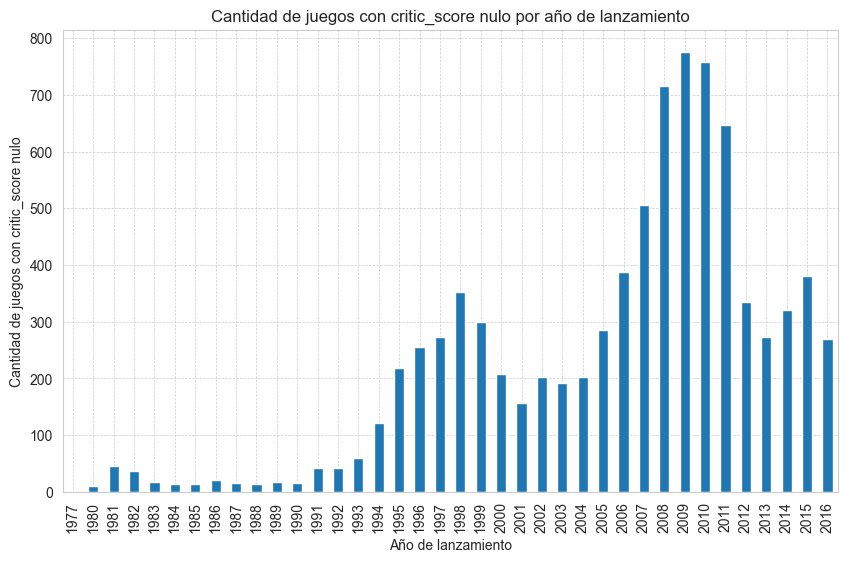

In [183]:
# Histograma de count por año sobre valores nulos en critic_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
juegos[juegos['critic_score'].isnull()]['year_of_release'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Cantidad de juegos con critic_score nulo')
plt.title('Cantidad de juegos con critic_score nulo por año de lanzamiento')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

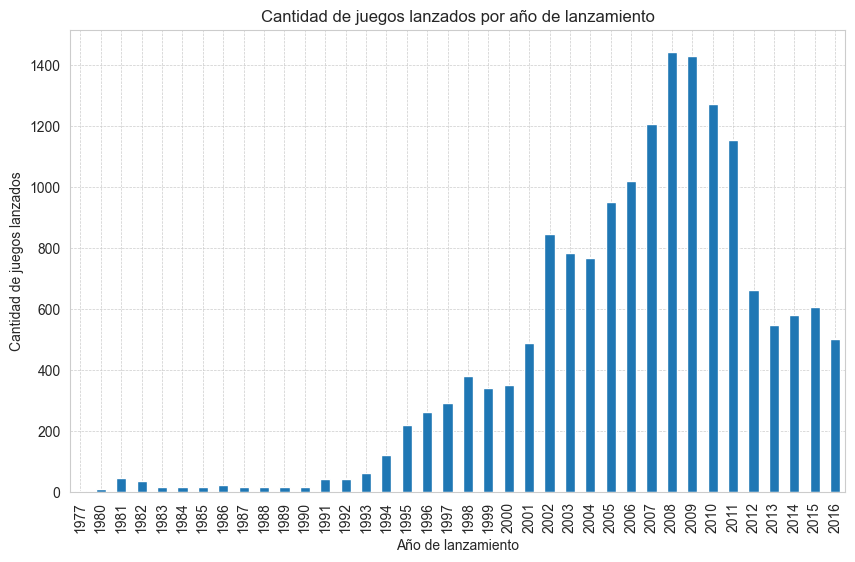

In [184]:
# histograma con cantidad de juegos por año de lanzamiento
plt.figure(figsize=(10, 6))
juegos['year_of_release'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Cantidad de juegos lanzados')
plt.title('Cantidad de juegos lanzados por año de lanzamiento')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

Por la cantidad neta de valores nulos en critic_score, se decide mantenerlos y no eliminarlos.

##### Valores nulos en user_score

In [185]:
juegos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16583 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16583 non-null  object 
 1   platform         16583 non-null  object 
 2   year_of_release  16583 non-null  Int64  
 3   genre            16583 non-null  object 
 4   na_sales         16583 non-null  float64
 5   eu_sales         16583 non-null  float64
 6   jp_sales         16583 non-null  float64
 7   other_sales      16583 non-null  float64
 8   critic_score     8086 non-null   float64
 9   user_score       7550 non-null   float64
 10  rating           16583 non-null  object 
 11  global_sales     16583 non-null  float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 1.7+ MB


La columna de user_score también tiene miles de valores nulos, eliminarlos significaría perder una gran cantidad de información, por lo que se decide mantenerlos y no eliminarlos. Por otro lado, rellenar esos valores nulos con la media o mediana de user_score podría distorsionar los resultados, ya que no se estaría considerando la variabilidad real de las calificaciones de los usuarios. Se dejarán también los valores nulos de rating por la misma razón.

#### Duplicados

In [186]:
# Analisis de duplicados
juegos.duplicated().sum()

0

No tenemos ningún duplicado por lo que no es necesario eliminar ningún valor por esta razón.

## Fase 3. Analisis de datos


En esta parte se realizará un análisis exploratorio de los datos para identificar patrones y tendencias. Se estudiará:

1) Juegos lanzados en diferentes años.
2) Comportamiento en las plataformas.
   1) Variación de ventas.
   2) Ciclo de vida de las distintas plataformas.
3) Seleccionar intervalos de tiempo relevantes.

Después de seleccionar los intervalos de tiempo relevantes se estudiará:

4) Plataformas líderes en ventas. Crecimiento y decreciemiento de plataformas.
5) Dispersión de ventas globales por plataforma.
6) Relación entre las opiniones de los usuarios y las ventas de la plataforma.
7) Comparación de videojuegos por plataforma.

Finalmente se buscará responder también a las preguntas ¿qué géneros son más rentables? y ¿hay características determinantes entre los géneros con más ventas y los géneros con menos ventas?

### Juegos lanzados en diferentes años

Veremos la cantidad de juegos lanzados por año así como las ganancias totales por año. Resaltaremos aquellos años en los que hubo un número significativo de lanzamientos y ganancias, el parámetro será el percentil 80 de la cantidad de juegos lanzados por año y el percentil 75 de las ganancias totales por año. Esto nos ayudará a identificar los años más activos en términos de lanzamientos de videojuegos y los años más exitosos en términos de ingresos generados por los videojuegos.

#### Tendencia de lanzamiento por año

In [187]:
# Lista de años con mayor cantidad de juegos lanzados. Se considerarán arriba del percentil 80 de la cantidad de juegos lanzados por año.
percentil_75 = juegos['year_of_release'].value_counts().quantile(0.75)
años_mayores_75 = juegos['year_of_release'].value_counts()[juegos['year_of_release'].value_counts() > percentil_75].index.tolist()
print(años_mayores_75)

[2008, 2009, 2010, 2007, 2011, 2006, 2005, 2002, 2003, 2004]


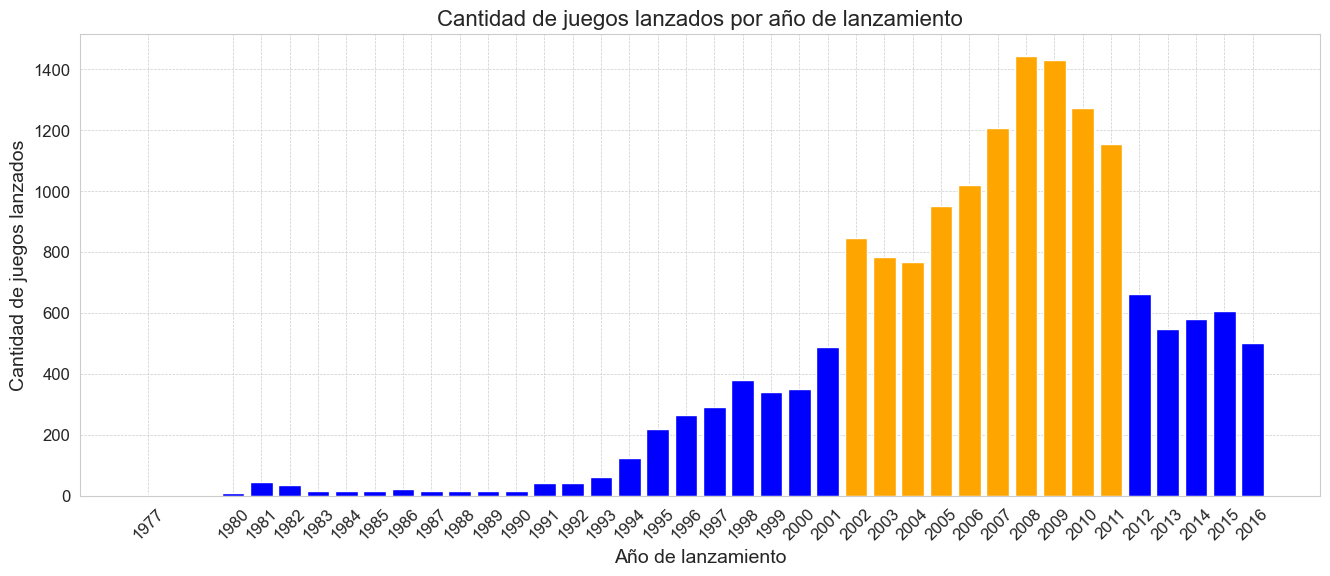

In [188]:
# Numéro de juegos lanzados por año
# Se resaltarán de otro color los valores dentro de años_mayores_75
plt.figure(figsize=(16, 6))
for year, count in juegos['year_of_release'].value_counts().sort_index().items():
    if year in años_mayores_75:
        plt.bar(year, count, color='orange')
    else:
        plt.bar(year, count, color='blue')

plt.xlabel('Año de lanzamiento', fontsize=14)
plt.ylabel('Cantidad de juegos lanzados', fontsize=14)
plt.title('Cantidad de juegos lanzados por año de lanzamiento', fontsize=16)
# Forzamos a ver todo los años en el eje x
plt.xticks(juegos['year_of_release'].value_counts().sort_index().index, rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


Esto quiere decir que los años que más lanzamientos fueron 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010 y 2011. Ahora vemos los años con más ventas.

#### Tendencia de ventas por año

In [189]:
# lista de años con mayores ganancias totales por año. Se considerarán aquellos años con ganancias totales por año arriba del percentil 75 de las ganancias totales por año.
ganancias_por_año = juegos.groupby('year_of_release')['global_sales'].sum()
percentil_75_ganancias = ganancias_por_año.quantile(0.75)
años_mayores_75_ganancias = ganancias_por_año[ganancias_por_año > percentil_75_ganancias].index.tolist()
print(años_mayores_75_ganancias)

[2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011]


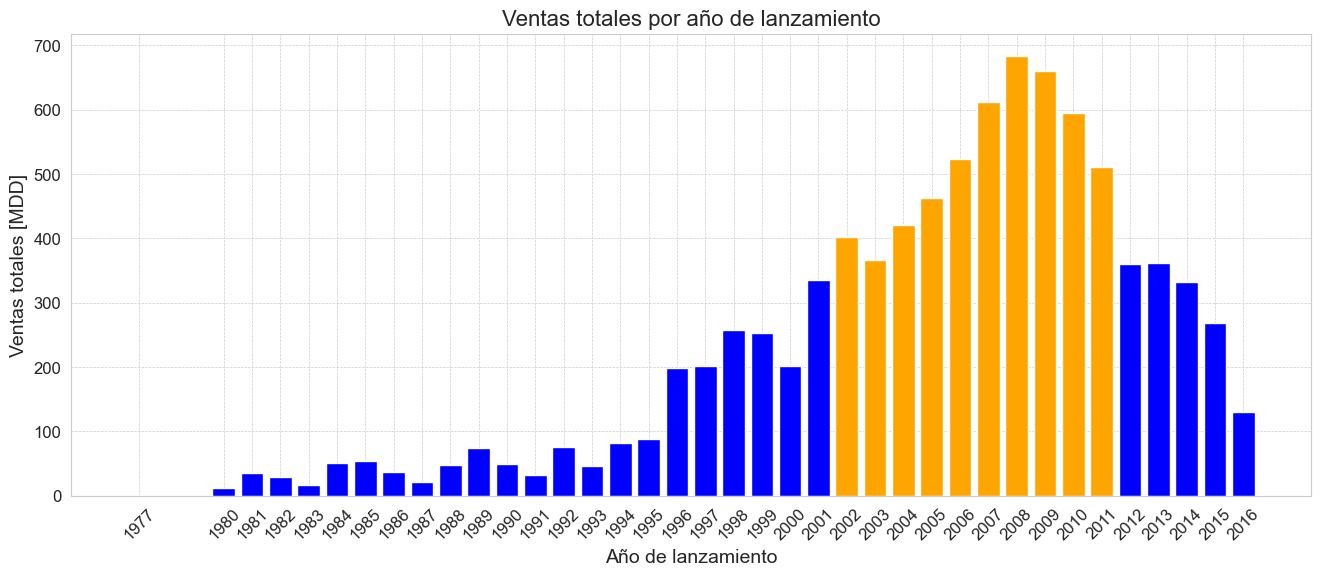

In [190]:
# histograma con los años con mayores ganancias totales por año resaltados de otro color
# se usará como referencia la lista años_mayores_75_ganancias para resaltar los años con mayores ganancias totales por año
plt.figure(figsize=(16, 6))
for year, ganancias in ganancias_por_año.sort_index().items():
    if year in años_mayores_75_ganancias:
        plt.bar(year, ganancias, color='orange')
    else:
        plt.bar(year, ganancias, color='blue')

plt.xlabel('Año de lanzamiento', fontsize=14)
plt.ylabel('Ventas totales [MDD]', fontsize=14)
plt.title('Ventas totales por año de lanzamiento', fontsize=16)
plt.xticks(ganancias_por_año.sort_index().index, rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

En este gráfico podemos ver los valores de ventas totales por año, resaltando aquellos años que se encuentran por encima del percentil 75 de las ganancias totales por año. Esto nos permite identificar visualmente los años más exitosos en términos de ingresos generados por los videojuegos. Los años que se destacan como los más exitosos son 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010 y 2011, lo que indica que durante ese período hubo un auge significativo en la industria de los videojuegos, con lanzamientos que generaron altos ingresos a nivel global.

Hay que notar algo en este análisis, algunos años con gran cantidad de lanzamientos son años con grandes ventas. Ahora analizaremos si esto es una tendencia general o si hay años con gran cantidad de lanzamientos pero con bajas ventas o viceversa. Calcularemos el coeficiente de correlación entre la cantidad de juegos lanzados por año y las ganancias totales por año para determinar si existe una relación significativa entre estas dos variables. Un coeficiente de correlación cercano a 1 indicaría una fuerte relación positiva, mientras que un valor cercano a 0 indicaría poca o ninguna relación. Esto nos ayudará a entender si los años con más lanzamientos tienden a ser también los años con mayores ganancias, o si hay casos donde esto no se cumple.

#### Correlación y ventas promedio por juego

In [191]:
# Correlación entre cantidad de juegos lanzados por año y ganancias totales por año
cantidad_juegos_por_año = juegos['year_of_release'].value_counts().sort_index()
ganancias_por_año = juegos.groupby('year_of_release')['global_sales'].sum().sort_index()
correlacion = cantidad_juegos_por_año.corr(ganancias_por_año)
print(f"Coeficiente de correlación: {correlacion:.2f}")

Coeficiente de correlación: 0.98


Esto quiere decir que los años con mayor ventas, en general, son también los años con mayor cantidad de lanzamientos. El indice de correlación de 0.98 indica una relación muy fuerte entre la cantidad de juegos lanzados por año. Ahora veamos esto de forma «promedio», es decir, veamos la relación entre la cantidad de ventas totales por año entre la cantidad de videojuegos por año y grafiquemos el resultado.

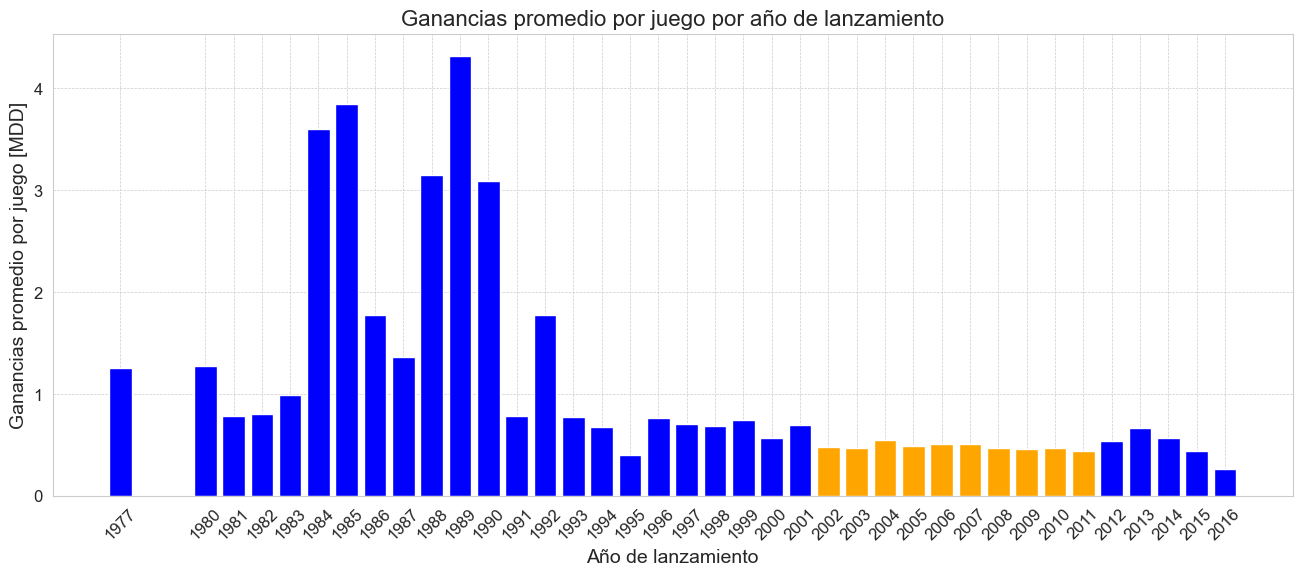

In [192]:
# Lista de valores promedio de ganancias totales por año entre la cantidad de lanzamientos por año
ganancias_promedio_por_año = round(ganancias_por_año / cantidad_juegos_por_año, 2)

# Histograma de ganancias promedio por año
plt.figure(figsize=(16, 6))
for year, ganancias in ganancias_promedio_por_año.sort_index().items():
    if year in años_mayores_75_ganancias:
        plt.bar(year, ganancias, color='orange')
    else:
        plt.bar(year, ganancias, color='blue')
plt.xlabel('Año de lanzamiento', fontsize=14)
plt.ylabel('Ganancias promedio por juego [MDD]', fontsize=14)
plt.title('Ganancias promedio por juego por año de lanzamiento', fontsize=16)
plt.xticks(ganancias_promedio_por_año.sort_index().index, rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

Esto muestra que, aunque un mayor número de lanzamientos por año está fuertemente correlacionado con mayores ganancias totales por año, no necesariamente implica que cada juego lanzado tenga un alto rendimiento en ventas. Existen años con pocos lanzamientos que, en promedio, generaron altas ganancias, lo que sugiere que la calidad o el éxito de los juegos lanzados en esos años pudo haber sido un factor importante. Por otro lado, años con muchos lanzamientos no garantizan altos ingresos si la mayoría de esos juegos no tuvieron un buen desempeño en el mercado. Esto resalta la importancia de no solo considerar la cantidad de lanzamientos, sino también la calidad y el atractivo de los juegos para los consumidores. Estas conclusiones se basan solo en los valores registrados en la base de datos estudiada, por lo que podrían existir otros factores externos no considerados que también influyen en las ventas de los videojuegos.

### Comportamiento en las plataformas

#### Variación de ventas

Ahora veamos cómo se ven las ventas cada año dependiendo de las plataformas.

In [193]:
# Lista de ventas totales por año de lanzamiento para cada plataforma ordenadas del año más reciente al más antiguo
ventas_totales__año_plataforma = juegos.groupby(['year_of_release', 'platform'])['global_sales'].sum().unstack(fill_value=0)
ventas_totales__año_plataforma = ventas_totales__año_plataforma.sort_index(ascending=False)
ventas_totales__año_plataforma.head()

platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
year_of_release,,,,,,,,,,,,,,,,,,,,,
2016,0.0,0.0,15.14,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.18,4.60,1.52,0.0,26.15
2015,0.0,0.0,27.78,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.14,16.35,11.96,0.0,60.14
2014,0.0,0.0,43.76,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.75,22.03,34.74,0.0,54.07
2013,0.0,0.0,56.57,0.0,1.54,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,8.59,21.65,88.58,0.0,18.96
2012,0.0,0.0,51.76,0.0,11.67,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,22.94,17.56,100.72,0.0,0.00


In [194]:
ventas_totales__año_plataforma.tail(10)

platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
year_of_release,,,,,,,,,,,,,,,,,,,,,
1988,0.74,0.0,0.0,0.0,0.00,1.43,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1987,1.94,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1986,0.67,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1985,0.45,0.0,0.0,0.0,0.02,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1984,0.27,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1983,5.84,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1982,28.88,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1981,35.68,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1980,12.68,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [195]:
import seaborn as sns
# import matplotlib.pyplot as plt

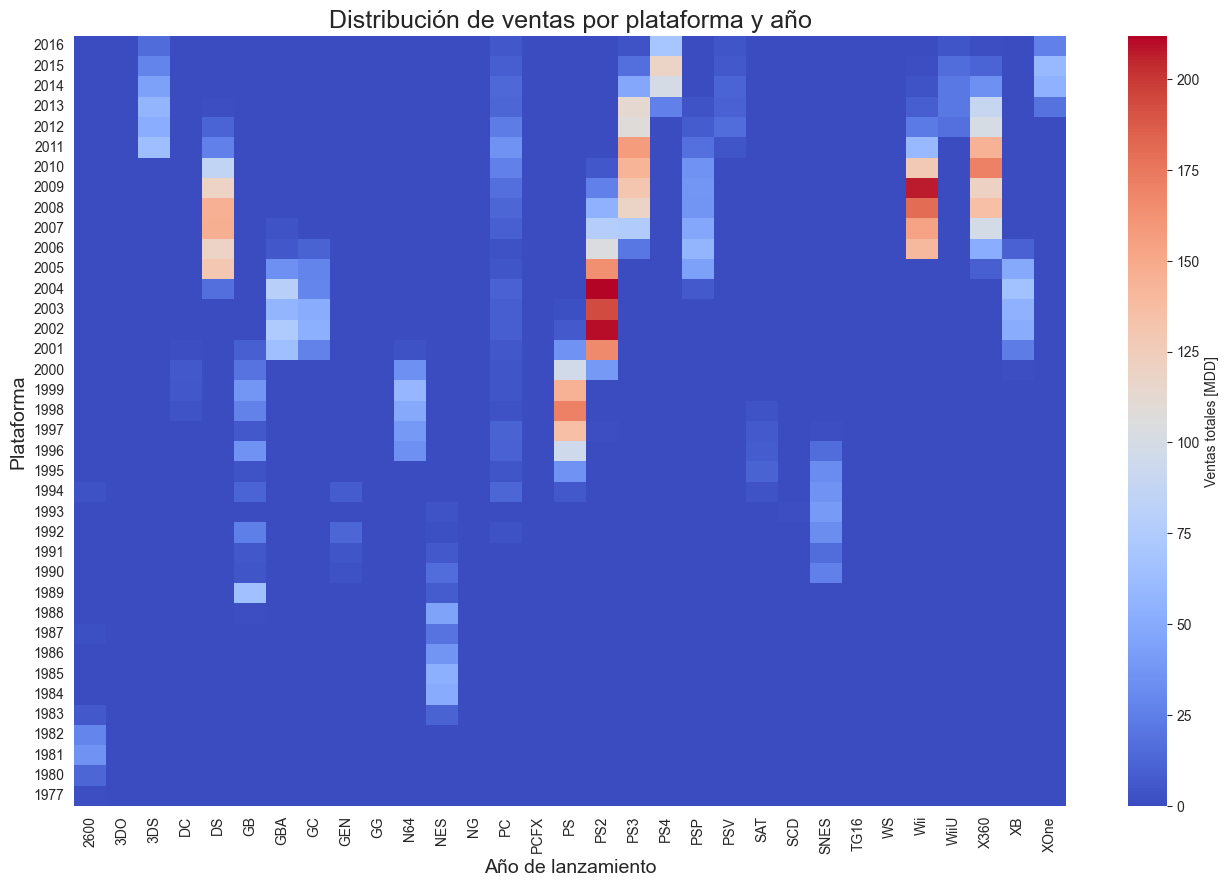

In [196]:
# Ventas totales por año de lanzamiento para cada plataforma en un heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(ventas_totales__año_plataforma, annot=False, cmap="coolwarm", cbar_kws={'label': 'Ventas totales [MDD]'})
plt.title('Distribución de ventas por plataforma y año', fontsize=18)
plt.xlabel('Año de lanzamiento', fontsize=14)
plt.ylabel('Plataforma', fontsize=14)
plt.show()

Esto nos da una idea general de cómo han evolucionado las ventas de videojuegos a lo largo del tiempo en diferentes plataformas. Podemos observar que algunas plataformas han tenido picos de ventas en ciertos años, mientras que otras han mostrado una tendencia más constante. Además, se pueden identificar los años en los que ciertas plataformas alcanzaron su punto máximo de popularidad y ventas, lo que puede estar relacionado con el lanzamiento de juegos exitosos o avances tecnológicos en esas plataformas.

Ahora se buscarán las plataformas líderes en ventas, basándose en el percentil 80 de la ventas totales por plataforma a lo largo del tiempo. 

In [197]:
# plataformas líderes en ventas, basándose en el percentil 80 de la ventas totales por plataforma a lo largo del tiempo
ventas_totales_por_plataforma = juegos.groupby('platform')['global_sales'].sum()
percentil_80_plataforma = ventas_totales_por_plataforma.quantile(0.80)
plataformas_lideres = ventas_totales_por_plataforma[ventas_totales_por_plataforma >= percentil_80_plataforma].sort_values(ascending=False)
print(plataformas_lideres)

platform
PS2     1252.26
X360     969.08
PS3      937.77
Wii      905.40
DS       804.88
PS       730.09
GBA      316.87
Name: global_sales, dtype: float64


Esto nos dice que
- PlayStation 2 (PS2) es la plataforma líder en ventas, seguida por
- Xbox 360 (X360),
- PlayStation 3 (PS3),
- Wii,
- Nintendo DS (DS),
- PlayStation (PS) y 
- Game Boy Advance (GBA).

Veamos nuevamente como se ve un mapa de calor de las ventas totales, por año, por plataforma hay.

In [198]:
# Columna adicional con los años minimo y maximo de lanzamiento por plataforma basandose en plataformas_lideres
años_min_max_plataforma = juegos[juegos['platform'].isin(plataformas_lideres.index)].groupby('platform')['year_of_release'].agg(['min', 'max'])
años_min_max_plataforma['año_min_max'] = años_min_max_plataforma.apply(lambda row: row['max'] - row['min'], axis=1)
años_min_max_plataforma = años_min_max_plataforma.sort_values(by='año_min_max', ascending=False)
años_min_max_plataforma = años_min_max_plataforma.merge(plataformas_lideres.rename('ventas_totales'), left_index=True, right_index=True)
años_min_max_plataforma

,min,max,año_min_max,ventas_totales
platform,,,,
DS,1985,2013,28,804.88
PS3,1991,2016,25,937.77
PS2,1997,2011,14,1252.26
X360,2005,2016,11,969.08
Wii,2006,2016,10,905.40
PS,1994,2003,9,730.09
GBA,2000,2007,7,316.87


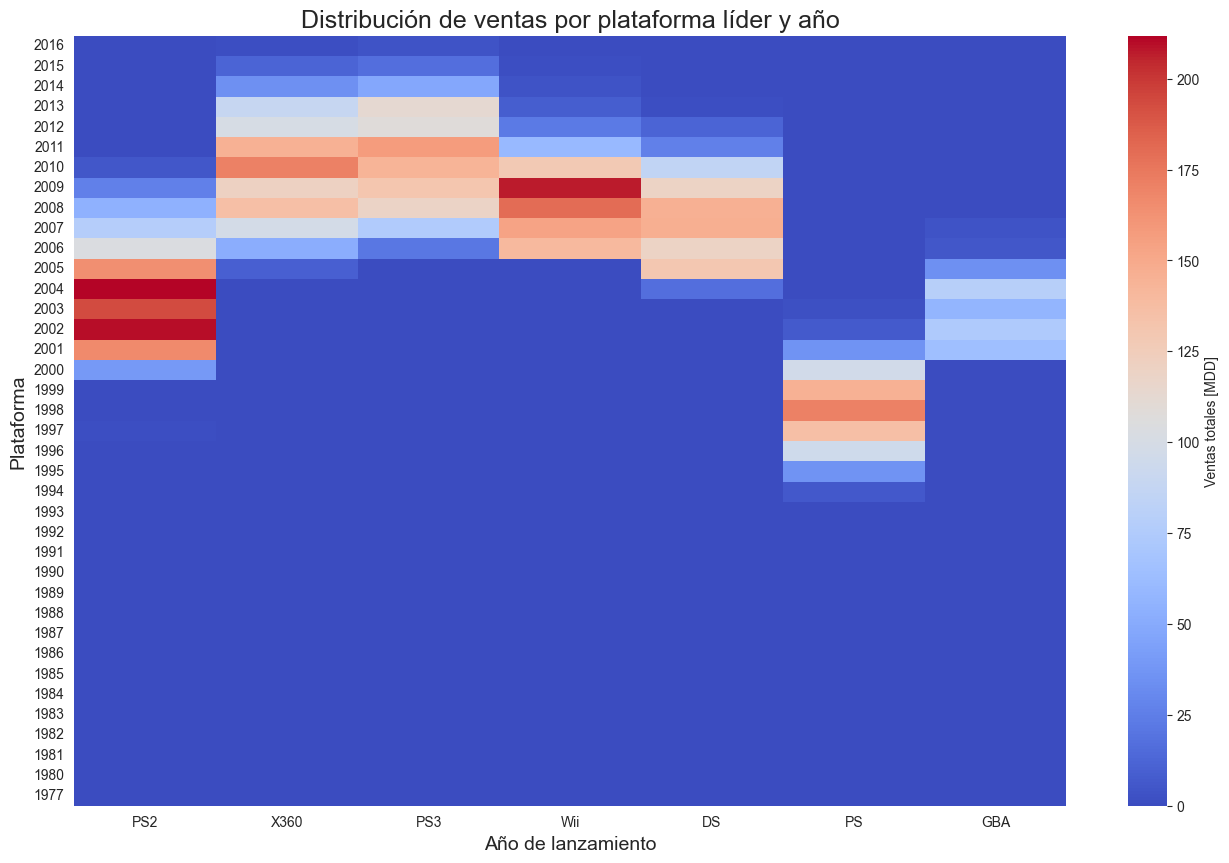

In [199]:
# mapa de calor de las ventas totales, por año, por plataforma usando plataformas_lideres
ventas_totales_lideres = ventas_totales__año_plataforma[plataformas_lideres.index]
plt.figure(figsize=(16, 10))
sns.heatmap(ventas_totales_lideres, annot=False, cmap="coolwarm", cbar_kws={'label': 'Ventas totales [MDD]'})
plt.title('Distribución de ventas por plataforma líder y año', fontsize=18)
plt.xlabel('Año de lanzamiento', fontsize=14)
plt.ylabel('Plataforma', fontsize=14)
#plt.ylim(1984, 2016)
plt.show()

#### Ciclo de vida de las distintas plataformas

En esta sección responderemos a las preguntas: 1) ¿cuánto tardan las plataformas antiguas en desaparecer? y 2) ¿cuánto tardan generalmente las nuevas plataformas en aparecer?

##### Tiempo de vida de las plataformas

Ahora analicemos el tiempo promedio de vida de las plataformas. Para esta primera parte seleccionaremos 
- aquellas plataformas que hayan tenido al menos 3 años de lanzamientos de videojuegos y 
- descartaremos aquellas plataformas que hayan tenido lanzamientos de videojuegos en los últimos 2 años del dataset (2015 y 2016) para evitar incluir plataformas que aún no han terminado su ciclo de vida.

Su ciclo de vida se definirá como el intervalo de tiempo entre el año de su primer lanzamiento y el primer año de su fase de declive.
Definiremos la «fase de declive» como el año donde sus ventas bajaron del 33 % de su pico máximo histórico y no volvieron a recuperarse.

Finalmente, con este intervalo de tiempo obtenido se calculará el tiempo promedio de vida de las plataformas y se analizará si existe alguna correlación entre el tiempo de vida de la plataforma y sus ventas totales.

In [200]:
# Ciclo de vida de las plataformas con más de 3 años de registro de ventas y con su última
# venta antes del 2014

ciclo_de_vida = juegos.groupby('platform')['year_of_release'].agg(['min', 'max'])
# Agregamos la columna de duración_total, para eliminar las plataformas con menos de 3 años de vida neta
ciclo_de_vida['duracion_total'] = ciclo_de_vida['max'] - ciclo_de_vida['min']
# ventas totales por plataforma
ciclo_de_vida['ventas_totales'] = juegos.groupby('platform')['global_sales'].sum()
ciclo_de_vida = ciclo_de_vida[(ciclo_de_vida['max'] <= 2014) & (ciclo_de_vida['duracion_total'] >= 3)].sort_values(by='duracion_total', ascending=False)
ciclo_de_vida

,min,max,duracion_total,ventas_totales
platform,,,,
DS,1985,2013,28,804.88
2600,1977,1994,17,91.56
PS2,1997,2011,14,1252.26
GB,1988,2001,13,254.43
NES,1983,1994,11,251.05
DC,1998,2008,10,15.95
PS,1994,2003,9,730.09
SNES,1990,1999,9,200.04
N64,1996,2004,8,218.48


Ahora se hará una función que encuentre el valor máximo de ventas por plataforma, encuentre el año donde las ventas bajaron del 33 % de ese valor máximo y no volvieron a recuperarse y calcule el tiempo de vida de la plataforma con base en esa información.

In [201]:
# Función para encontrar el año de declive de una plataforma
def año_declive(plataforma):
    """
    Función para encontrar el año de declive de una plataforma, definido como el año donde sus ventas bajaron 
    del 33 % de su pico máximo histórico y no volvieron a recuperarse.
    """
    # Obtenemos las ventas por año para la plataforma
    ventas_plataforma = juegos[juegos['platform'] == plataforma].groupby('year_of_release')['global_sales'].sum().sort_index()
    
    # Encontramos el pico máximo de ventas de la plataforma
    pico_maximo = ventas_plataforma.max()
    umbral_declive = pico_maximo * 0.33
    año_declive = None
    
    # Filtramos la tabla para considerar solo los años posteriores al pico máximo
    ventas_plataforma = ventas_plataforma[ventas_plataforma.index > ventas_plataforma.idxmax()] 

    for año, ventas in ventas_plataforma.items():
        if ventas < umbral_declive:
            return año
    # si no hubo declive y la plataforma dejó de reportar ventas después de su pico máximo, 
    # se considera que el año de declive es el último año registrado
    return ventas_plataforma.index[-1]

In [202]:
# aplicamos el criterio creando una nueva columna con el año de declive
ciclo_de_vida['año_declive'] = ciclo_de_vida.index.to_series().apply(año_declive)
ciclo_de_vida['tiempo_de_vida'] = ciclo_de_vida['año_declive'] - ciclo_de_vida['min']

# ordenamos por tiempo de vida
ciclo_de_vida = ciclo_de_vida.sort_values(by='tiempo_de_vida', ascending=False)
ciclo_de_vida

,min,max,duracion_total,ventas_totales,año_declive,tiempo_de_vida
platform,,,,,,
DS,1985,2013,28,804.88,2011,26
PS2,1997,2011,14,1252.26,2008,11
PS,1994,2003,9,730.09,2001,7
SNES,1990,1999,9,200.04,1997,7
2600,1977,1994,17,91.56,1983,6
NES,1983,1994,11,251.05,1989,6
XB,2000,2008,8,256.69,2006,6
GBA,2000,2007,7,316.87,2006,6
N64,1996,2004,8,218.48,2001,5


In [203]:
# correlación entre el tiempo de vida de la plataforma y sus ventas totales
print(f"Coeficiente de correlación entre duración de la plataforma y ventas totales: {ciclo_de_vida['tiempo_de_vida'].corr(ciclo_de_vida['ventas_totales']):.2f}")

Coeficiente de correlación entre duración de la plataforma y ventas totales: 0.64


Podemos que ver hay una correlación positiva de 0.64 entre la duración de la plataforma y sus ventas totales, lo que sugiere que las plataformas que han estado activas durante más tiempo tienden a generar mayores ventas totales. Esto podría deberse a que las plataformas con una vida útil más larga han tenido más oportunidades para lanzar juegos exitosos y construir una base de usuarios leales, lo que a su vez contribuye a mayores ingresos a lo largo del tiempo. Sin embargo, es importante tener en cuenta que esta correlación no implica causalidad, y otros factores como la calidad de los juegos lanzados, la competencia en el mercado y las tendencias tecnológicas también pueden influir en las ventas totales de una plataforma.

In [204]:
# promedio de vida de las plataformas
print(f"Promedio de vida de las plataformas: {ciclo_de_vida['tiempo_de_vida'].mean():.2f} años")

Promedio de vida de las plataformas: 6.73 años


Al pasar los filtros mencionados anteriormente obtuvimos 15 plataformas con un **tiempo de vida promedio de 6.13 años**.

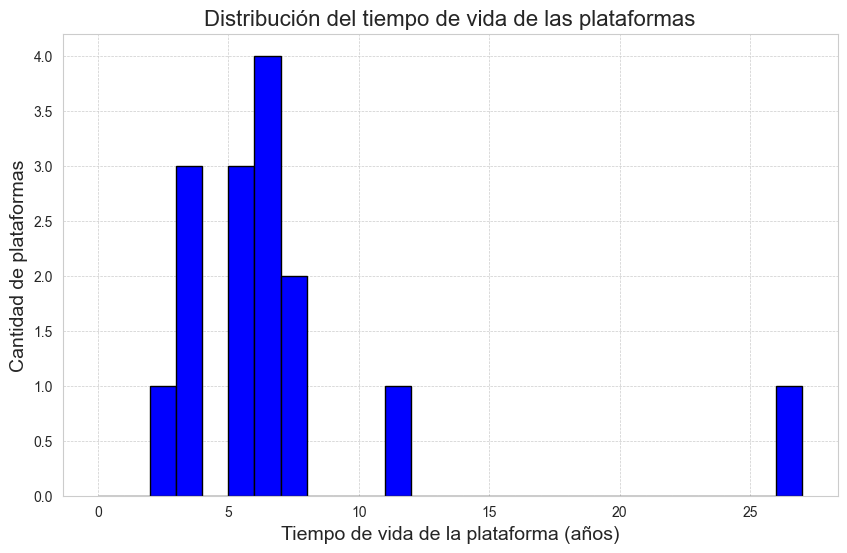

In [205]:
# histograma del tiempo de vida de las plataformas
plt.figure(figsize=(10, 6))
plt.hist(ciclo_de_vida['tiempo_de_vida'], bins=range(0, ciclo_de_vida['tiempo_de_vida'].max() + 2, 1), color='blue', edgecolor='black')
plt.xlabel('Tiempo de vida de la plataforma (años)', fontsize=14)
plt.ylabel('Cantidad de plataformas', fontsize=14)
plt.title('Distribución del tiempo de vida de las plataformas', fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [206]:
# mediana del tiempo de vida de las plataformas
print(f"Mediana del tiempo de vida de las plataformas: {ciclo_de_vida['tiempo_de_vida'].median():.2f} años")

Mediana del tiempo de vida de las plataformas: 6.00 años


Al ver la tabla del ciclo de vida y el histograma anterior podemos ver que hay un sesgo en el promedio por valores atípicos altos. En este caso también resaltaremos la mediana del tiempo de vida que es de **6 años**. 

Esto quiere decir que las plataformas tardan en desaparecer alrededor de los 6 años, 6.13 en promedio con una mediana de 6 años. Sin embargo, es importante considerar que algunas plataformas pueden tener ciclos de vida más largos debido a factores como el éxito de sus juegos exclusivos, la lealtad de su base de usuarios o su capacidad para adaptarse a las tendencias del mercado.

##### Tiempo de reaparición de las plataformas

Para este análisis tendremos que clasificar las plataformas por familias, es decir, agrupar aquellas plataformas que son parte de la misma familia pero con distintas generaciones. Por ejemplo, PS1, PS2 y PS3 pertenecen a la familia de PlayStation. Xbox y Xbox 360 pertenecen a la familia de Xbox. También se clasificarán como portable o no portable, que llamaremos «portable» y «home», respectivamente.

Después, el tiempo de reaparición de una plataforma se definirá como el tiempo de lanzamiento de una generación nueva menos el años de lanzamiento de la anterior generación.

\begin{equation}
T_{reaparición} = año_{nueva} - año_{anterior}
\end{equation}

Volvamos a ver los tipos de plataformas que tenemos en el data set.

In [207]:
juegos['platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne',
       'WiiU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

Podemos ver una gran variadad de plataformas, sin embargo, nos centraremos en las plataformas de las familias de PlayStation, Xbox y Nintendo, ya que son las más representativas y tienen varias generaciones que nos permitirán analizar el tiempo de reaparición de manera más efectiva.

Plataformas como PC se mantienen a lo largo del tiempo sin una generación nueva, por lo que no se incluirán en este análisis. Por otro lado, plataformas como retro como SNES o Sega Genesis no tienen una generación nueva, por lo que tampoco se incluirán en este análisis.

In [208]:
# clasificiación de plataformas por familias y tipo (portable o home)
def agrupar_plataforma(p):
    """
    Función para agrupar plataformas por familias y tipo (portable o home).
    """
    if p in ['PS', 'PS2', 'PS3', 'PS4']: return 'Sony_home'
    if p in ['PSP', 'PSV']: return 'Sony_port'
    if p in ['X360', 'XB', 'XOne']: return 'MS_home'
    if p in ['Wii', 'NES', 'SNES', 'N64', 'WiiU', 'GC']: return 'Nintendo_home'
    if p in ['DS', 'GB', 'GBA', '3DS']: return 'Nintendo_port'
    if p == 'PC': return 'PC'
    return 'Otras_retro'

In [209]:
ciclo_de_aparicion = juegos.groupby('platform')['year_of_release'].agg(['min', 'max'])
ciclo_de_aparicion['platform_group'] = ciclo_de_aparicion.index.to_series().apply(agrupar_plataforma)

# Quitamos otras_retro y PC para enfocarnos en las plataformas más relevantes
ciclo_de_aparicion = ciclo_de_aparicion[~ciclo_de_aparicion['platform_group'].isin(['Otras_retro', 'PC'])]
ciclo_de_aparicion

,min,max,platform_group
platform,,,
3DS,2000,2016,Nintendo_port
DS,1985,2013,Nintendo_port
GB,1988,2001,Nintendo_port
GBA,2000,2007,Nintendo_port
GC,2001,2007,Nintendo_home
N64,1996,2004,Nintendo_home
NES,1983,1994,Nintendo_home
PS,1994,2003,Sony_home
PS2,1997,2011,Sony_home


In [210]:
import numpy as np

In [211]:
# función para calcular el promedio de reaparición de las plataformas por familia, 
# considerando solo las familias con más de una plataforma y ordenando los años de 
# lanzamiento para asegurar deltas positivos
def promedio_reaparicion(df_ciclo):
    """
    Calcula el promedio de reaparición de las plataformas por familia.
    
    Parámetros:
        df_ciclo (DataFrame): DataFrame que contiene las columnas 'platform_group' y 'min' (año de lanzamiento).
    return:
        DataFrame: DataFrame con el promedio de reaparición de cada familia.
    """
    # Agrupamos por familia y extraemos los años de lanzamiento (min)
    # Ordenamos los años para cada familia para asegurar deltas positivos
    lanzamientos_por_familia = df_ciclo.groupby('platform_group')['min'].apply(lambda x: sorted(x.unique()))
    
    resultados = []
    
    for familia, años in lanzamientos_por_familia.items():
        # Si hay más de una plataforma, calculamos los intervalos
        if len(años) > 1:
            # np.diff calcula la diferencia entre elementos consecutivos
            intervalos = np.diff(años)
            promedio = np.mean(intervalos)
        else:
            # Si solo hay una plataforma, el intervalo es indefinido (NaN)
            promedio = np.nan
            
        resultados.append({'familia': familia, 'promedio_reaparicion_años': promedio})
    
    # Convertimos a DataFrame y ponemos la familia como índice
    df_resultado = pd.DataFrame(resultados).set_index('familia')
    
    return df_resultado

In [212]:
# Aplicamos la función
tabla_reaparicion = promedio_reaparicion(ciclo_de_aparicion)

# Mostramos el resultado final
print(tabla_reaparicion)
print(f"\nPromedio global de la industria: {tabla_reaparicion['promedio_reaparicion_años'].mean():.2f} años")

               promedio_reaparicion_años
familia                                 
MS_home                         6.500000
Nintendo_home                   5.800000
Nintendo_port                   7.500000
Sony_home                       7.333333
Sony_port                       7.000000

Promedio global de la industria: 6.83 años


Esto nos dice que el promedio de años que tarda en reaparecer una nueva plataforma es de 6.83 años, lo que sugiere que, en promedio, las empresas de videojuegos lanzan nuevas generaciones de plataformas aproximadamente cada 6 a 7 años. Este intervalo de tiempo puede estar influenciado por factores como los avances tecnológicos, la competencia en el mercado y las estrategias de marketing de las empresas. Otra nort importante es ver cómo se acopla este tiempo de reaparición con el tiempo de vida de las plataformas que también ronda los 6 años, lo que podría indicar que las empresas lanzan nuevas generaciones de plataformas justo cuando las anteriores están llegando al final de su ciclo de vida, buscando así mantener el interés de los consumidores y asegurar una transición suave entre generaciones.

### Intervalos de tiempo relevantes

Como el propósito del proyecto es identificar patrones que determinen si un videojuego tiene éxito o no, es importante seleccionar intervalos de tiempo relevantes para el análisis. Para esto se seleccionarán los años entre 2013 y 2016 ya que son los años más recientes en el dataset y es importante analizar los patrones de éxito de los videojuegos en un contexto más actual, considerando las tendencias y preferencias de los consumidores en los últimos años. Además, estos años incluyen lanzamientos de plataformas como PlayStation 4 (PS4) y Xbox One, que son relevantes para el análisis de plataformas líderes en ventas.

### Plataformas líderes

Primero veamos qué plataformas aún tienen presencia en este intervalo de tiempo. Crearemos un nuevo DataFrame con los juegos lanzados entre 2013 y 2016 para analizar las plataformas líderes en ventas durante ese período.

In [213]:
juegos_recientes = juegos[juegos['year_of_release'] >= 2013]
juegos_recientes['platform_group'] = juegos_recientes['platform'].apply(agrupar_plataforma)
juegos_recientes.head()

C:\Users\jltg_\AppData\Local\Temp\ipykernel_2856\1889700863.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  juegos_recientes['platform_group'] = juegos_recientes['platform'].apply(agrupar_plataforma)


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,platform_group
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05,Sony_home
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27,MS_home
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,unknown,14.63,Sony_home
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,unknown,14.60,Nintendo_port
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62,Sony_home


In [214]:
juegos_recientes.groupby('platform')['global_sales'].sum().sort_values(ascending=False)

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       40.06
PSV      32.99
Wii      13.66
PSP       3.74
DS        1.54
Name: global_sales, dtype: float64

In [215]:
ciclo_de_vida

,min,max,duracion_total,ventas_totales,año_declive,tiempo_de_vida
platform,,,,,,
DS,1985,2013,28,804.88,2011,26
PS2,1997,2011,14,1252.26,2008,11
PS,1994,2003,9,730.09,2001,7
SNES,1990,1999,9,200.04,1997,7
2600,1977,1994,17,91.56,1983,6
NES,1983,1994,11,251.05,1989,6
XB,2000,2008,8,256.69,2006,6
GBA,2000,2007,7,316.87,2006,6
N64,1996,2004,8,218.48,2001,5


Aquí podemos ver que las 5 plataformas líderes en ventas durante el período de 2013 a 2016 son:
1) PlayStation 4 (PS4),
2) PlayStation 3 (PS3),
3) Xbox One (XOne),
4) 3DS y 
5) Xbox 360 (X360)

mientras que una que al analizar la tabla del ciclo de vida podemos ver que Nintendo DS si bien aún tiene ventas, por ahber incluído el 2013, ya se encuentra en su fase de declive, específicamente en su último año de vida. Analicemos este comportamiento con un mapa de calor.

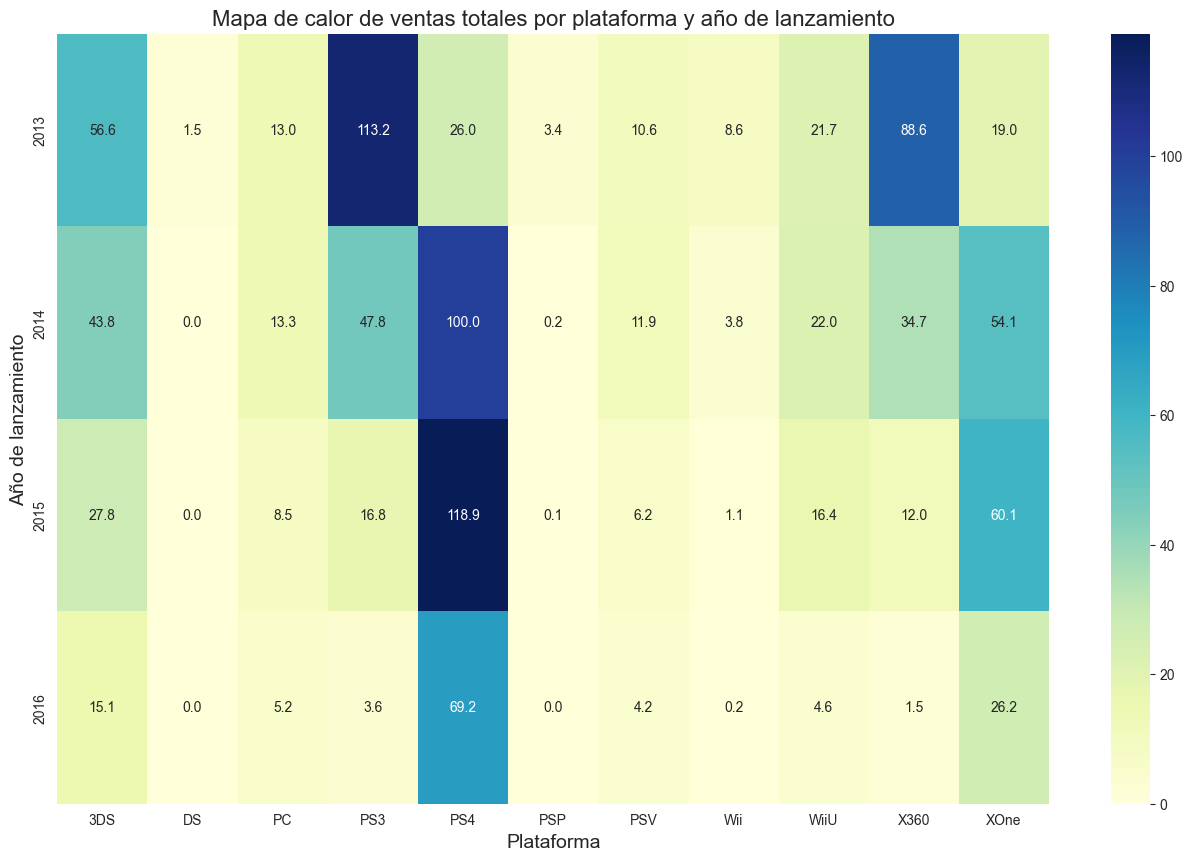

In [216]:
# Mapa de calor de ventas totales por plataforma y año de lanzamiento en juegos_recientes
ventas_totales_recientes = juegos_recientes.groupby(['year_of_release', 'platform'])['global_sales'].sum().unstack(fill_value=0)

plt.figure(figsize=(16, 10))
sns.heatmap(ventas_totales_recientes, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Mapa de calor de ventas totales por plataforma y año de lanzamiento", fontsize=16)
plt.xlabel("Plataforma", fontsize=14)
plt.ylabel("Año de lanzamiento", fontsize=14)
plt.show()

En este intervalo de tiempo podemos ver que las últimas en la lista como DS y PSP ya no registraron ventas en el 2016. Otra característica importantes es que todas las plataformas tienden una tendencia a la baja en ventas. Por otro lado, PS4 aún no podemos decir que esté en su fase de declive ya que este año, si bien tiene menos ventas que el anterior, aún no cumple con nuestro criterio de tener 33 % del máximo histórico de ventas y no haberse recuperado, por lo que podría encontrarse aún en fase de crecimiento, de forma análoga sucede con Xbox One.

Esto posiciona a PS4 y a Xbox One como las plataformas líderes en ventas durante el año 2016.

### Dispersión de ventas globales por plataforma

Para continuar el análisis se volverá a filtrar y se estudiarán las top 5 plataformas líderes en este intervalo de tiempo, es decir, PS4, PS3, Xbox One, 3DS y Xbox 360. Se creará un diagrama de caja clasificado por plataforma para analizar la dispersión de las ventas globales por plataforma.

In [217]:
# Filtro adicional considerando solo las top 5 plataformas en juegos_recientes
top_5_plataformas_recientes = juegos_recientes.groupby('platform')['global_sales'].sum().sort_values(ascending=False).head(5).index
juegos_recientes_top5 = juegos_recientes[juegos_recientes['platform'].isin(top_5_plataformas_recientes)].reset_index(drop=True)
juegos_recientes_top5.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,platform_group
0,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05,Sony_home
1,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27,MS_home
2,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,unknown,14.63,Sony_home
3,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,unknown,14.60,Nintendo_port
4,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62,Sony_home


In [218]:
plataformas_lideres_actuales = juegos_recientes_top5['platform'].unique()

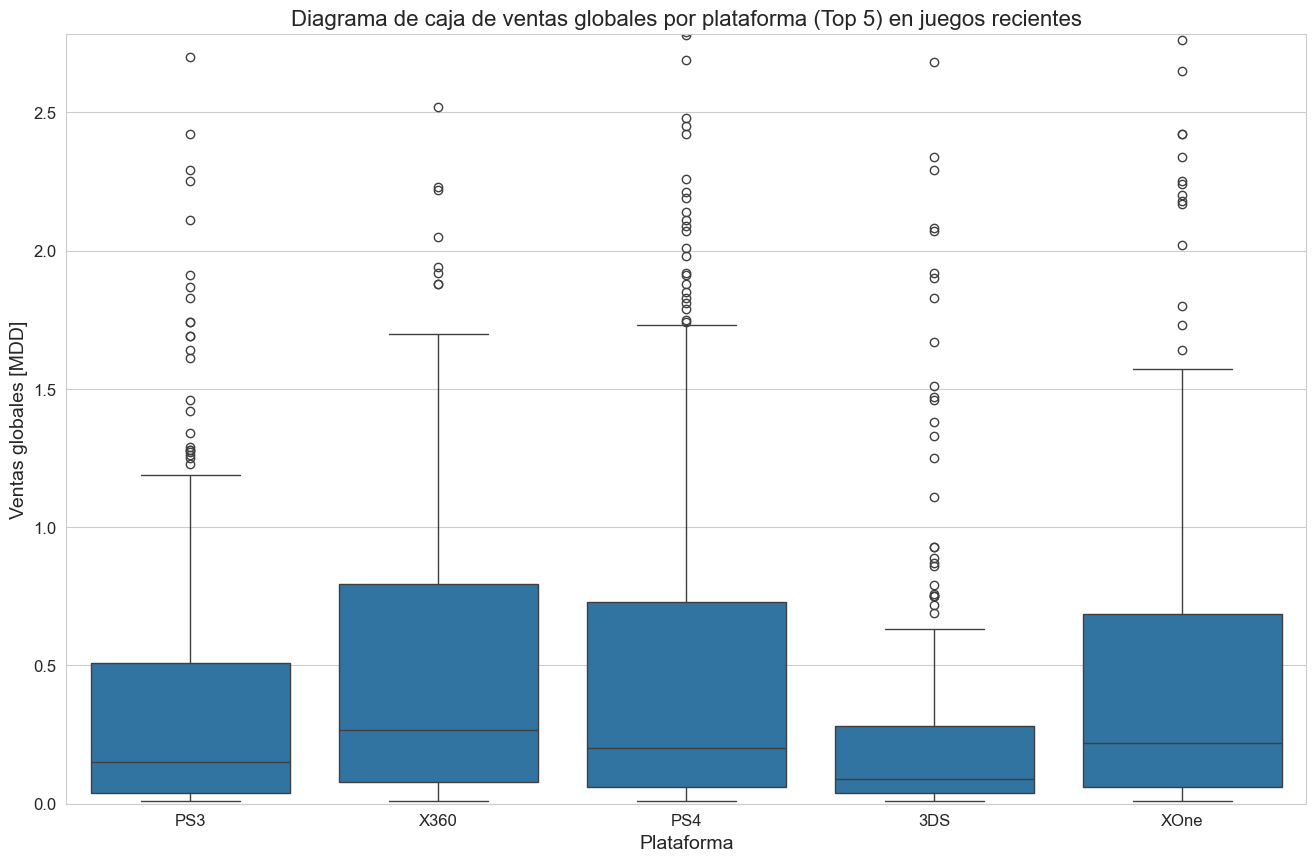

In [219]:
# diagrama de caja clasificado por plataforma para analizar la dispersión de las ventas globales por plataforma en juegos_recientes_top5
plt.figure(figsize=(16, 10))
sns.boxplot(x='platform', y='global_sales', data=juegos_recientes_top5)
plt.title("Diagrama de caja de ventas globales por plataforma (Top 5) en juegos recientes", fontsize=16)
plt.xlabel("Plataforma", fontsize=14)
plt.ylabel("Ventas globales [MDD]", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, juegos_recientes_top5['global_sales'].quantile(0.95))
plt.show()

En el gráfico podemos ver mucho outliers y medias muy cercanas. Algunas cosas relevantes es que el intervalor intercuartilico de PS4, Xbox One y Xbox 360 es más amplio que el de 3DS y el de PS3, esto quiere decir que hay una mayor dispersión en las ventas de estas 3 plataformas respecto a las ultimas 2 mencionadas. Veamos estos valores más a detalle con una descripción estadística de las ventas globales por plataforma.

In [220]:
juegos_recientes_top5.groupby('platform')['global_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
3DS,303.0,0.472772,1.381347,0.01,0.04,0.090,0.280,14.60
PS3,345.0,0.525884,1.451939,0.01,0.04,0.150,0.510,21.05
PS4,392.0,0.801378,1.609456,0.01,0.06,0.200,0.730,14.63
X360,186.0,0.735484,1.663275,0.01,0.08,0.265,0.795,16.27
XOne,247.0,0.645020,1.036139,0.01,0.06,0.220,0.685,7.39


Aquí podemos ver varias cosas. La plataforma con mayor venta promedio es PS4 pero su mediana es muy inferior a su media, lo que sugiere que hay algunos juegos en PS4 que han tenido ventas excepcionalmente altas, lo que eleva la media, pero la mayoría de los juegos en PS4 tienen ventas más bajas, lo que se refleja en la mediana. Xbox One tiene un comportamiento similar pero con un promedio de ventas menor que PS4 pero medianas muy cercanas.

Todos los juegos tienen una mediana muy baja respecto a su media, lo que sugiere que la mayoría de los juegos en estas plataformas tienen ventas bajas, mientras que unos pocos juegos tienen ventas muy altas, lo que eleva la media. Esto podría indicar que el éxito de los videojuegos en estas plataformas es altamente variable, con algunos títulos alcanzando un gran éxito comercial mientras que la mayoría no logra generar ventas significativas.

### Relación entre las opiniones de los usuarios y las ventas de plataformas

Ahora veamos la correlación entre las opiniones de los ususarios, y profesionales; y las ventas globales por plataforma. Tomaremos como base las líderes en ventas en el intervalo que estamos trabajando, es decir, 2013-2016. Para esto se calculará el coeficiente de correlación entre las ventas globales y las calificaciones de los usuarios y profesionales para cada plataforma líder en ventas durante el período de 2013 a 2016. Esto nos ayudará a entender si existe una relación significativa entre las opiniones de los usuarios y profesionales y el éxito comercial de los videojuegos en estas plataformas, lo que podría indicar que las calificaciones positivas están asociadas con mayores ventas.

Primero veamos una grafica de dispersión con PS4 y Xbox One, que son las plataformas líderes en ventas durante el año 2016.

In [221]:
import seaborn as sns

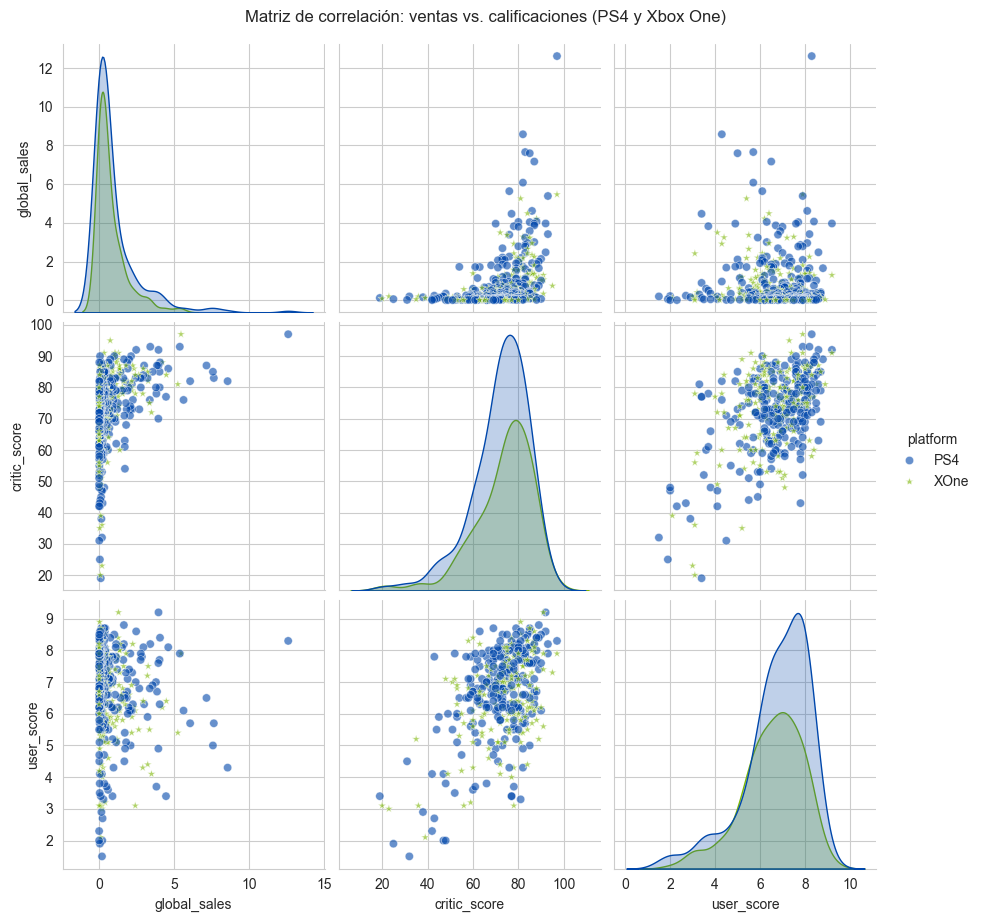

In [222]:
# Seleccionamos solo las columnas de interés
columnas_interes = ['platform', 'global_sales', 'critic_score', 'user_score']
df_ps4_Xone = juegos_recientes_top5[juegos_recientes_top5['platform'].isin(['PS4', 'XOne'])]
df_ps4_Xone = df_ps4_Xone[columnas_interes].dropna() # Eliminamos nulos para el cálculo

# Creamos el pairplot
sns.pairplot(df_ps4_Xone, 
             height=3, 
             diag_kind='kde', 
             plot_kws={'alpha':0.6}, 
             hue='platform',
             palette={'PS4': "#0047AB", 'XOne': '#7DB707'},
             markers = {'PS4': 'o', 'XOne': '*'})
plt.suptitle('Matriz de correlación: ventas vs. calificaciones (PS4 y Xbox One)', y=1.02)
plt.show()

Aquí podemos obtener las primeras conclusiones preliminares. El comportamiento es similar entre PS4 y Xbox One, pareciera haber una correlación positiva entre critic_score y user_score, sin embargo no parece haber una correlación clara entre las ventas globales y alguna calificación ya sea de críticos o usuarios. Ahora se graficará una matriz de correlaciones para ver los valores puntuales de correlación entre las ventas globales, critic_score y user_score para cada plataforma líder en ventas durante el período de 2013 a 2016. 

In [223]:
import math

In [224]:
def visualizar_matrices_correlacion(df, plataformas):
    # Configuración de la cuadrícula (layout)
    n_plataformas = len(plataformas)
    cols = 2  
    rows = math.ceil(n_plataformas / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
    axes = axes.flatten() # Aplanamos para iterar fácilmente si es una matriz 2D
    
    # Iteración por cada plataforma
    for i, plataforma in enumerate(plataformas):
        # Filtramos y limpiamos datos para esta plataforma específica
        df_plat = df[df['platform'] == plataforma].copy()
        df_plat['user_score'] = pd.to_numeric(df_plat['user_score'], errors='coerce')
        
        # Calculamos la matriz (solo variables de interés)
        columnas = ['global_sales', 'critic_score', 'user_score']
        matriz_corr = df_plat[columnas].corr()
        
        # Dibujamos el Heatmap en el subplot correspondiente
        sns.heatmap(
            matriz_corr, 
            annot=True, 
            fmt=".2f", 
            cmap="RdBu_r", # Rojo para positivo, Azul para negativo (centrado en 0)
            center=0,
            ax=axes[i],
            cbar_kws={'label': 'Coeficiente R de Pearson'}
        )
        
        axes[i].set_title(f'Matriz: {plataforma}', fontsize=14, fontweight='bold')
    
    # Limpieza de subplots vacíos (si n_plataformas es impar)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle('Comparativa de correlaciones: ventas vs. calificaciones (2013-2016)', fontsize=18)
    plt.show()

Ahora veamos con cada uno de las 5 plataformas

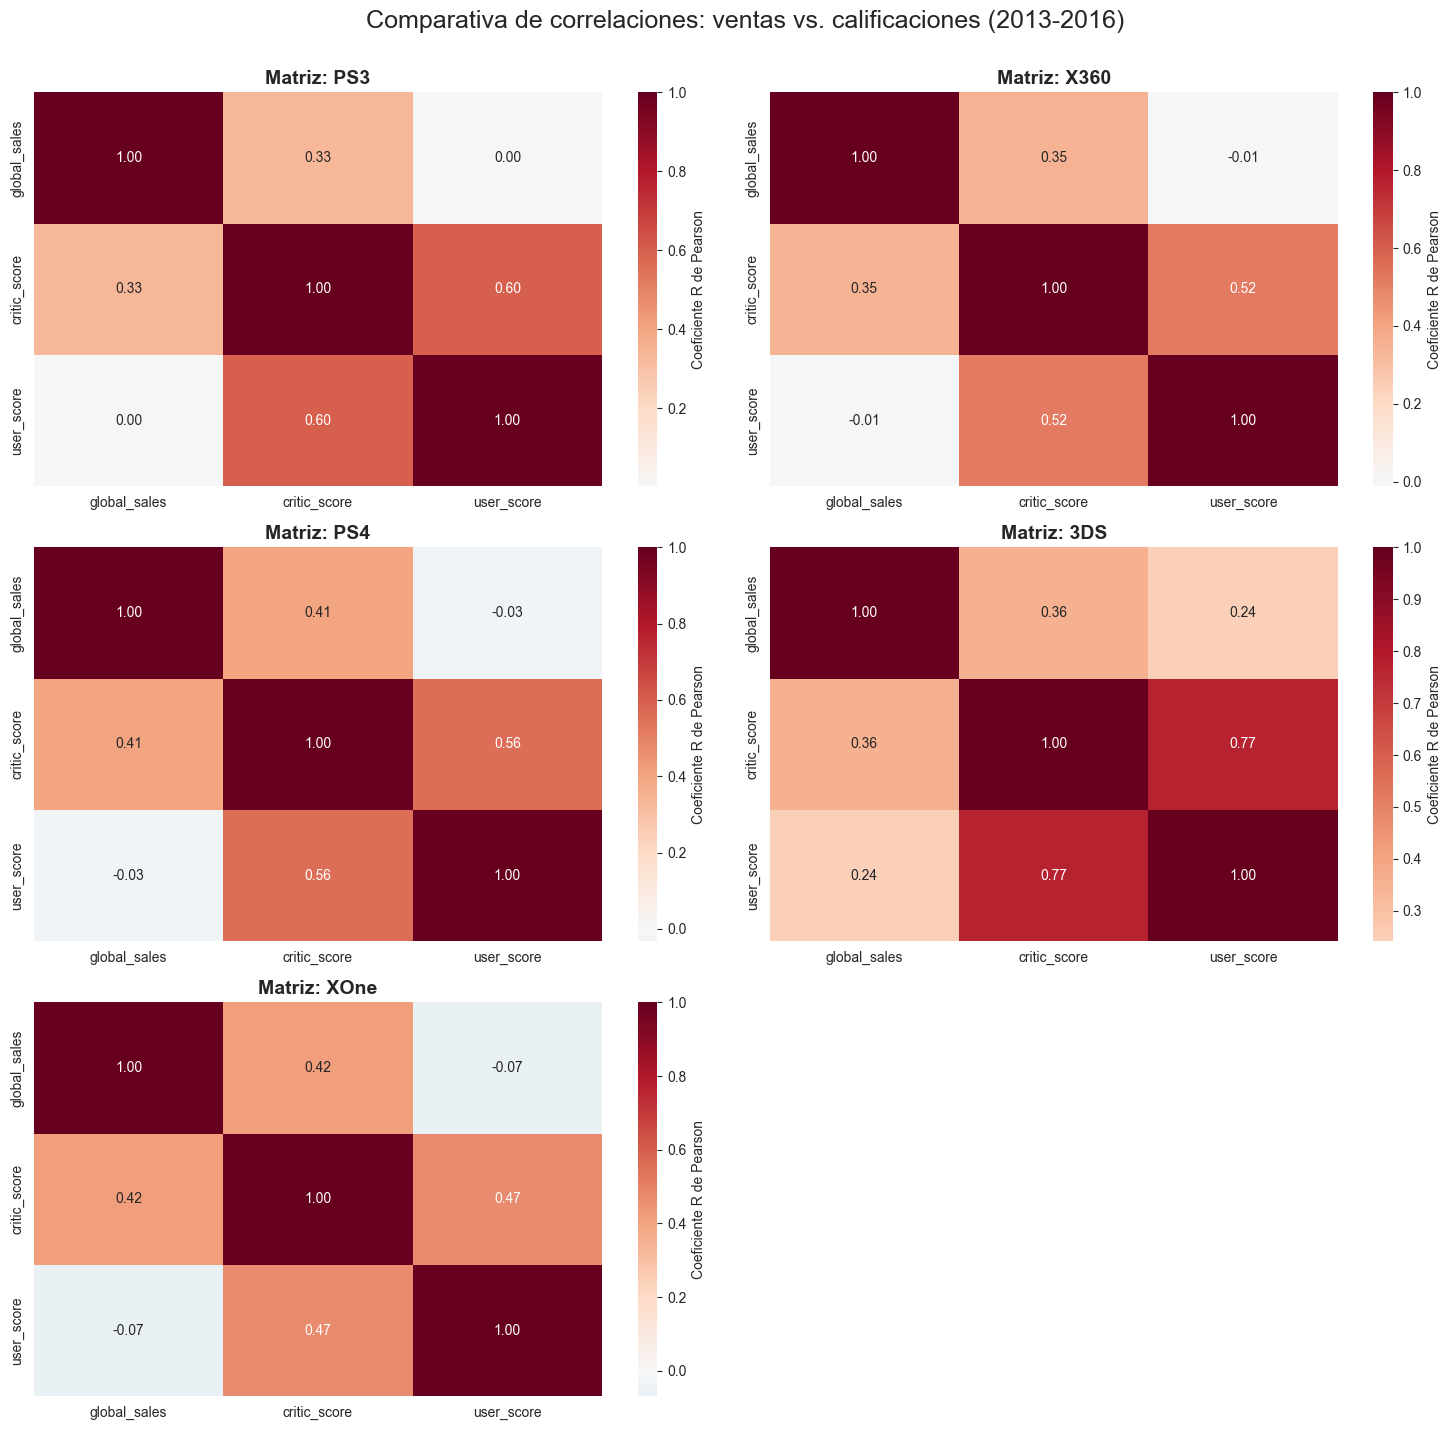

In [225]:
# usamos subplot para ver cada matriz de correlación por plataforma líder en ventas durante el período de 2013 a 2016
visualizar_matrices_correlacion(juegos_recientes_top5, plataformas_lideres_actuales)

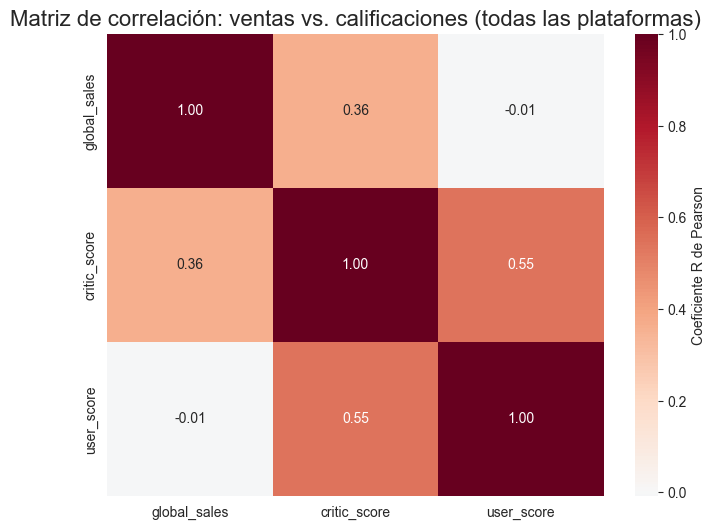

In [226]:
# Gráfica de la matriz de correlación de todas las plataformas combinadas
columnas = ['global_sales', 'critic_score', 'user_score']
matriz_corr_combinada = juegos_recientes_top5[columnas].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_corr_combinada, 
    annot=True, 
    fmt=".2f", 
    cmap="RdBu_r", 
    center=0,
    cbar_kws={'label': 'Coeficiente R de Pearson'}
)
plt.title('Matriz de correlación: ventas vs. calificaciones (todas las plataformas)', fontsize=16)
plt.show()

Podemos ver algo importante. En la plataforma seleccionada, PS4, hay una ligera correlación positiva entre las ventas globales y el critic_score, lo que sugiere que los juegos con mejores calificaciones de los críticos tienden a tener mayores ventas. Sin embargo, no se observa una correlación significativa entre las ventas globales y el user_score, lo que podría indicar que las opiniones de los usuarios no tienen un impacto tan fuerte en las ventas como las opiniones de los críticos en esta plataforma.

En general todas las plataformas tienen este comportamiento, es decir, una ligera correlación positiva entre las ventas globales y el critic_score, pero no una correlación significativa entre las ventas globales y el user_score. Esto podría sugerir que, en estas plataformas, las calificaciones de los críticos tienen un mayor impacto en el éxito comercial de los videojuegos que las calificaciones de los usuarios. Sin embargo, es importante tener en cuenta que esta conclusión se basa únicamente en los datos registrados en la base de datos estudiada, y otros factores externos no considerados también podrían influir en las ventas de los videojuegos.

### Comparación de ventas por género

Ahora se compararán las ventas globales por género para cada plataforma líder en ventas durante el período de 2013 a 2016. Esto nos ayudará a identificar si ciertos géneros de videojuegos tienden a tener un mejor desempeño comercial en estas plataformas, lo que podría ser útil para planificar campañas publicitarias y estrategias de desarrollo de juegos en el futuro.

Veamos cuántos géneros de videojuegos hay en el dataset.

In [227]:
print("Cantidad de géneros únicos en juegos_recientes_top5:", len(juegos_recientes_top5['genre'].unique()))
print("Géneros únicos en juegos_recientes_top5:", juegos_recientes_top5['genre'].unique())

Cantidad de géneros únicos en juegos_recientes_top5: 12
Géneros únicos en juegos_recientes_top5: ['Action' 'Shooter' 'Role-Playing' 'Misc' 'Sports' 'Fighting' 'Simulation'
 'Racing' 'Platform' 'Adventure' 'Puzzle' 'Strategy']


In [228]:
juegos_recientes_top5.groupby('genre')['global_sales'].sum().sort_values(ascending=False)

genre
Action          285.96
Shooter         216.22
Sports          142.48
Role-Playing    127.83
Misc             43.57
Racing           31.46
Fighting         27.91
Platform         22.88
Adventure        18.59
Simulation       13.05
Strategy          3.20
Puzzle            1.79
Name: global_sales, dtype: float64

Esta primera visualización nos deja en claro que los géneros con más ventas globales son 
- Action,
- Shooter,
- Sports, 
- Role-Playing y 
- Misc.

Se analizará a detalle los número por medio de una pivot table y un mapa de calor.

In [229]:
# pivot table con género y plataforma para analizar las ventas globales
ventas_por_genero_plataforma = juegos_recientes_top5.pivot_table(values='global_sales', index='genre', columns='platform', aggfunc='sum', fill_value=0)
ventas_por_genero_plataforma

platform,3DS,PS3,PS4,X360,XOne
genre,,,,,
Action,34.04,70.92,96.10,47.59,37.31
Adventure,3.33,4.32,6.34,1.92,2.68
Fighting,8.21,6.05,8.65,2.55,2.45
Misc,7.10,8.36,8.19,12.49,7.43
Platform,8.79,3.33,7.69,2.14,0.93
Puzzle,1.73,0.04,0.02,0.00,0.00
Racing,0.00,6.46,12.14,3.07,9.79
Role-Playing,67.37,16.49,28.99,4.43,10.55
Shooter,0.06,31.79,88.56,35.48,60.33


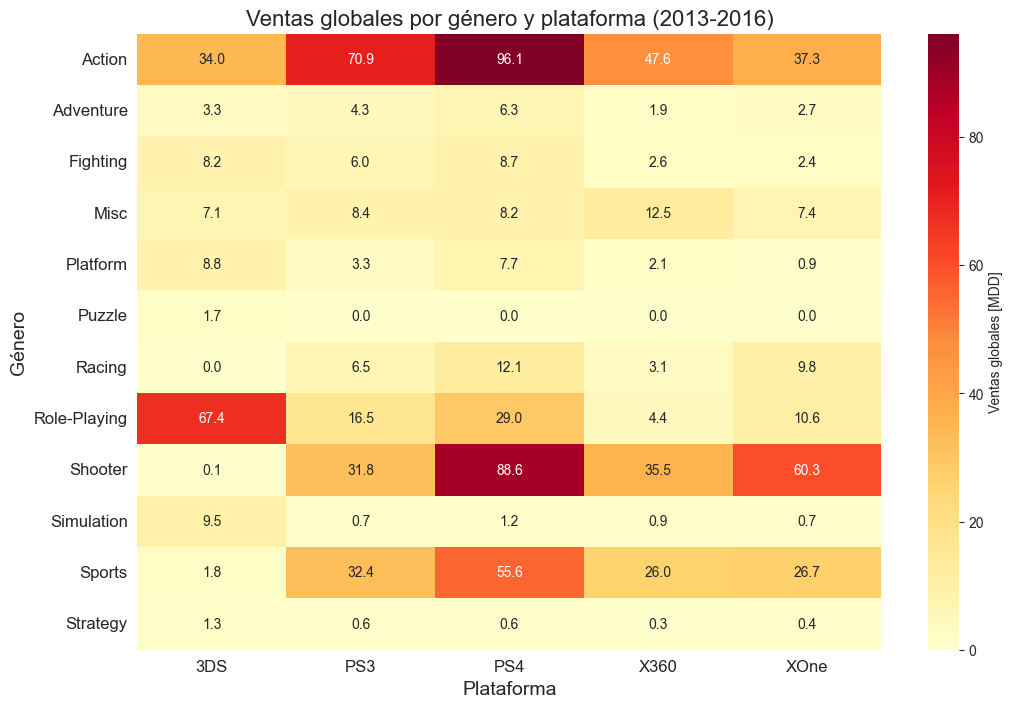

In [230]:
# gráfica de calor representando la pivot table de ventas por género y plataforma
plt.figure(figsize=(12, 8))
sns.heatmap(ventas_por_genero_plataforma, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Ventas globales [MDD]'})
plt.title('Ventas globales por género y plataforma (2013-2016)', fontsize=16)
plt.xlabel('Plataforma', fontsize=14)
plt.ylabel('Género', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Podemos ver que la plataforma lider de ventas, **PS4**, tiene una gran cantidad de ventas en **Action** y **Shooter**. Este comportamiento se repirt con Xbox One, aunque con ventas menores que PS4. En el caso de 3DS, el género con más ventas es **Role-Playing** y en el caso de Xbox 360 es **Action**.

Los géneros con **menos ventas globales** son **Puzzle** y **Strategy**. 

La mayoría de plataformas presentar un comportameinto semejante, salvo **3DS** que tiene más ventas por **Role-Playing** que por **Action**. Además esta plataforma es la única que tiene ventas reportadas en **Puzzle**.

### Conclusiones generales del análisis de datos

Los **géneros más rentables** son **Action**, **Shooter**, **Sports** y **Role-Playing**. Estos géneros tienden a tener un mejor desempeño comercial en las plataformas líderes de ventas durante el período de 2013 a 2016, lo que sugiere que los consumidores tienen una preferencia por estos tipos de juegos. Por otro lado, los **géneros con menos ventas globales** son **Puzzle** y **Strategy**, lo que podría indicar que estos tipos de juegos tienen un nicho de mercado más pequeño o que no generan tanto interés entre los consumidores en comparación con los géneros más populares.

En cuanto a las plataformas más rentables, **PS4 es la plataforma líder en ventas durante el período de 2013 a 2016, seguida por Xbox One**. Estas plataformas han demostrado ser exitosas en términos de ingresos generados por los videojuegos lanzados en ellas, lo que podría estar relacionado con la calidad de los juegos disponibles, la lealtad de su base de usuarios y su capacidad para adaptarse a las tendencias del mercado. Estas plataformas podrían aún encontrarse en fase de crecimiento, lo que sugiere que podrían seguir generando altos ingresos en el futuro si continúan lanzando juegos exitosos y manteniendo el interés de los consumidores.

Las demás plataformas presentan un declive en su número de ventas año tras año.

## Fase 4. Perfil de usuario por región.

Para esta fase tendremos 3 secciones relevantes:
1) Se describirán las variaciones de las cuotas de mercado entre regiones, basándose en las 5 plataformas principales.
2) Se analizará la diferencia entre los 5 géneros principales.
3) Se analizará si las clasificaciones de ESRB afectan las ventas en cada región.

### Variaciones de las cuotas de mercado entre regiones

Primero crearemos 3 dataframes donde solo tengamos la información de ventas asociada a esa región. Las regiones que trabajaremos son Norteamérica (NA), Europa (EU) y Japón (JP). Para esto eliminaremos las columnas de ventas que no correspondan a cada región, ya que nos enfocaremos en el mercado específico de cada una. Dejaremos la columna de ventas globales.

In [231]:
juegos_recientes.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,platform_group
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05,Sony_home
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27,MS_home
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,unknown,14.63,Sony_home
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,unknown,14.60,Nintendo_port
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62,Sony_home


In [232]:
# Para region_NA eliminamos las columnas de eu_sales, jp_sales y other_sales, ya que nos enfocaremos en el mercado norteamericano
region_NA = juegos_recientes[['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'critic_score', 'user_score', 'rating']]
region_NA.head()

,name,platform,year_of_release,genre,na_sales,critic_score,user_score,rating
16,Grand Theft Auto V,PS3,2013,Action,7.02,97.0,8.2,M
23,Grand Theft Auto V,X360,2013,Action,9.66,97.0,8.1,M
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,NaN,NaN,unknown
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,NaN,NaN,unknown
42,Grand Theft Auto V,PS4,2014,Action,3.96,97.0,8.3,M


In [233]:
# procedemos de forma análoga para las regiones de Europa y Japón creando dataframes separados para cada región con las columnas relevantes para cada una
region_EU = juegos_recientes[['name', 'platform', 'year_of_release', 'genre', 'eu_sales', 'critic_score', 'user_score', 'rating']]
region_JP = juegos_recientes[['name', 'platform', 'year_of_release', 'genre', 'jp_sales', 'critic_score', 'user_score', 'rating']]

In [234]:
# cinco plataformas principales de cada región basándonos en las ventas totales por plataforma en cada región
top_5_plataformas_NA = region_NA.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
top_5_plataformas_NA

platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

In [235]:
top_5_plataformas_EU = region_EU.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
top_5_plataformas_EU

platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64

In [236]:
top_5_plataformas_JP = region_JP.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)
top_5_plataformas_JP

platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64

In [237]:
# unimos cada dataframe donde cada columna es una región diferente y sus valores son las plataformas líderes en ventas para cada región
# esto para comparar el órden de las plataformas en cada región
comparativa_plataformas = pd.DataFrame({
    'NA': top_5_plataformas_NA.index,
    'EU': top_5_plataformas_EU.index,
    'JP': top_5_plataformas_JP.index
})
comparativa_plataformas.index = [1, 2, 3, 4, 5]
comparativa_plataformas

,NA,EU,JP
1,PS4,PS4,3DS
2,XOne,PS3,PS3
3,X360,XOne,PSV
4,PS3,X360,PS4
5,3DS,3DS,WiiU


Esto nos muestra que tanto en Norteamérica como en Europa, la plataforma líder en ventas es PlayStation 4 (PS4). Un aspecto interesante es que en Japón, la plataforma líder en ventas es Nintendo 3DS (3DS), la cual es la plataforma con menor ventas globales entre las plataformas líderes en ventas en Norteamérica y Europa. Esto podría indicar que los consumidores japoneses tienen una preferencia por los juegos disponibles en 3DS, lo que podría estar relacionado con la popularidad de ciertos géneros de juegos o con la presencia de títulos exclusivos para esa plataforma que resuenan más con el público japonés.

### Diferencia entre los 5 géneros principales

Ahora se analizará la diferencia entre los 5 géneros principales en cada región. Para esto se creará un mapa de calor con las ventas globales por género para cada región.

In [238]:
# Dataframe con las ventas totales por género en cada región para las plataformas líderes de cada región
ventas_genero_NA = region_NA.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
ventas_genero_NA

genre
Action          126.13
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64

In [239]:
ventas_genero_EU = region_EU.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
ventas_genero_EU

genre
Action          118.61
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64

In [240]:
ventas_genero_JP = region_JP.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)
ventas_genero_JP

genre
Role-Playing    51.04
Action          40.49
Misc             9.44
Fighting         7.65
Shooter          6.61
Name: jp_sales, dtype: float64

In [241]:
# unimos las tablas para comparar los géneros más vendidos en cada región
comparativa_generos = pd.DataFrame({
    'NA': ventas_genero_NA.index,
    'EU': ventas_genero_EU.index,
    'JP': ventas_genero_JP.index
})
comparativa_generos

,NA,EU,JP
0,Action,Action,Role-Playing
1,Shooter,Shooter,Action
2,Sports,Sports,Misc
3,Role-Playing,Role-Playing,Fighting
4,Misc,Racing,Shooter


Nuevamente encontramos un comportamiento similar donde el top 4 se comparte, es decir, Action, Shooter, Sports y Role-Playing son los géneros con más ventas en Norteamérica y Europa, mientras que en Japón el género con más ventas globales es Role-Playing, seguido por Action.

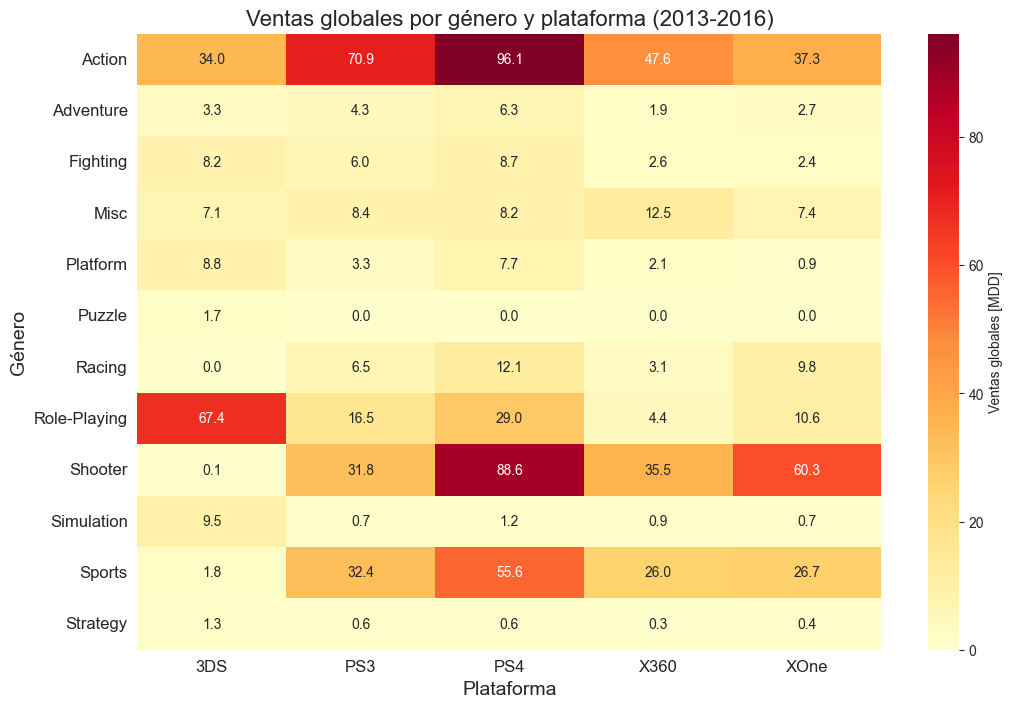

In [242]:
# gráfica de calor representando la pivot table de ventas por género y plataforma
plt.figure(figsize=(12, 8))
sns.heatmap(ventas_por_genero_plataforma, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Ventas globales [MDD]'})
plt.title('Ventas globales por género y plataforma (2013-2016)', fontsize=16)
plt.xlabel('Plataforma', fontsize=14)
plt.ylabel('Género', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Si recordamos la distribución de géneros por plataforma, de la sección previa; vimos que 3DS tenía más ventas en Role-Playing que en Action, lo que podría explicar por qué el género con más ventas globales en Japón es Role-Playing, ya que 3DS es la plataforma líder en ventas en esa región. Por otro lado, en Norteamérica y Europa, donde PS4 es la plataforma líder en ventas y tiene una gran cantidad de ventas en Action y Shooter, estos géneros se posicionan como los más rentables en esas regiones.

### Clasificaciones de ESRB y ventas por región

Primero recordemos que la clasificación de ESRB es un sistema de clasificación de contenido para videojuegos que asigna una clasificación de edad y contenido a cada juego.
Para nuestro datasert, las clasificaciones de ESRB encontradas son:
- **E (Everyone)**: contenido apto para todo público.
- **E10+ (Everyone 10+)**: contenido apto para mayores de 10 años.
- **T (Teen)**: contenido apto para adolescentes de 13 años en adelante.
- **M (Mature 17+)**: contenido apto para mayores de 17 años.
- **AO (Adults Only 18+)**: contenido solo para adultos.
- **EC (Early Childhood)**: contenido dirigido a niños pequeños.
- **RP (Rating Pending)**: clasificación aún no asignada oficialmente.

Veremos un histograma de las ventas por región en función de la clasificación de ESRB para ver si hay alguna preferencia por parte de los consumidores en cada región hacia ciertos tipos de contenido.

In [243]:
juegos_recientes['rating'].unique()

array(['M', 'unknown', 'E', 'T', 'E10+'], dtype=object)

Para los juegos recientes tenemos solo 4 clasificaciones: M, E, T y E10+; además de clasificaciones de desconocidos 'unknown'.

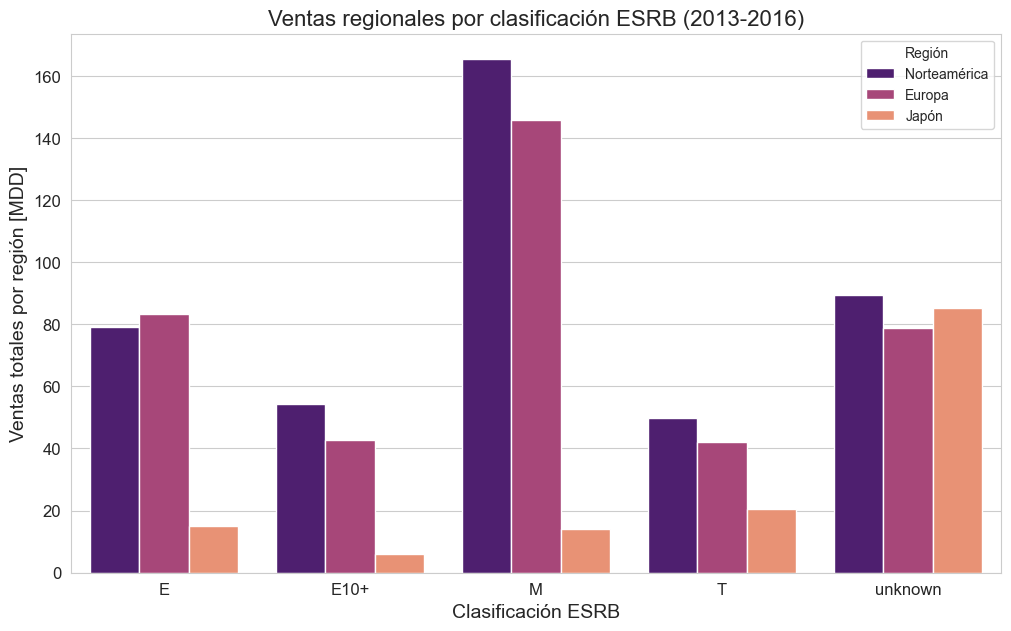

In [249]:
# Agrupamos las ventas por rating para las tres regiones
rating_comparativa = juegos_recientes.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum().reset_index()
rating_comparativa.columns = ['rating', 'Norteamérica', 'Europa', 'Japón']

# Transformamos el DataFrame a formato largo (melt)
df_tidy = rating_comparativa.melt(id_vars='rating', var_name='region', value_name='ventas_region')

# Creamos el gráfico de barras agrupadas
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# El parámetro 'hue' es el que crea las barras agrupadas por región
sns.barplot(data=df_tidy, x='rating', y='ventas_region', hue='region', palette='magma')

plt.title('Ventas regionales por clasificación ESRB (2013-2016)', fontsize=16)
plt.xlabel('Clasificación ESRB', fontsize=14)
plt.ylabel('Ventas totales por región [MDD]', fontsize=14)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.legend(title='Región')
plt.show()

Nuevamente los comportamientos entre Norteamérica y Europa son similares, siendo la clasificación M (Mature 17+) la que tiene más ventas, seguida por E (Everyone), para Europa; y 'unknown' para Norteamérica. Esto podría indicar que los consumidores en estas regiones tienen una preferencia por juegos con contenido más maduro, aunque también hay un interés significativo en juegos aptos para todo público. Una posible causa es que el consumidor promedio en estas regiones es un adolescente o adulto joven, lo que podría explicar la preferencia por juegos con contenido más maduro.

Por otro lado, es interesante notar que en Japón las clasificación con mayor número de ventas es 'unknown', lo que podría indicar que una gran cantidad de juegos populares en esa región no tienen una clasificación de ESRB asignada, lo que podría deberse a diferencias en los sistemas de clasificación de contenido entre regiones o a la presencia de juegos exclusivos para el mercado japonés que no siguen las mismas pautas de clasificación.

Esto indica que la clasificación de ESRB muestra una relación con las ventas en cada región, con preferencias claras hacia ciertos tipos de contenido en Norteamérica y Europa, mientras que en Japón la falta de clasificación de ESRB para muchos juegos populares sugiere que otros factores podrían estar influyendo en las ventas en esa región. La clasificación ESRB sí afecta las ventas en cada región, pero su impacto varía dependiendo de las preferencias culturales y demográficas de los consumidores en cada región.

## Fase 5. Análisis inferencial. Validación estadística de puntos clave para el plan 2017

Tras el análisis exploratorio de los datos, sruge la necesidad de validad estadísticamente algunas tendencias observadas. No se compararán solo la medias y medianas, algo que ya se hizo en el análisis exploratorio, sino que se realizarán pruebas de hipótesis para determinar si las diferencias observadas entre plataformas y géneros son estadísticamente significativas o si podrían haber ocurrido por casualidad. Para esto se realizarán pruebas de hipótesis, dependiendo del número de grupos que se estén comparando, para evaluar si las calificaciones promedio de los usuarios difieren significativamente entre las plataformas líderes en ventas y entre los géneros más populares. Esto nos ayudará a entender mejor si las preferencias de los usuarios están realmente asociadas con ciertas plataformas o géneros, lo que podría ser útil para la toma de decisiones en el desarrollo y marketing de videojuegos.

Las líneas que seguiremos a continuación son:
- **Xbox One vs PC**. Dado que Microsoft ha desarrollado tanto Xbox One como juegos para PC, ¿percibe el usuario una experiencia de juego similar en ambas plataformas, lo que se reflejaría en calificaciones de usuarios similares? Esto podría indicar que los usuarios valoran la calidad de los juegos y la experiencia de juego de manera consistente, independientemente de la plataforma, lo que podría ser un indicio de que la marca Xbox tiene una reputación sólida tanto en consolas como en PC.
- **Acción vs Deportes**. Dado que los juegos de acción y deportes son dos géneros populares con características de juego muy diferentes, ¿existen diferencias significativas en la satisfacción del usuario entre estos géneros? Esto podría indicar que los usuarios tienen preferencias claras por ciertos tipos de juegos, lo que podría ser útil para los desarrolladores y comercializadores de videojuegos al planificar futuros lanzamientos y estrategias de marketing.

Otras líneas interesantes son:
- **PS4 vs Xbox One**. Dado que PS4 y Xbox One son las plataformas líderes en ventas durante el período de 2013 a 2016, ¿existen diferencias significativas en las calificaciones de los usuarios entre estas dos plataformas? Esto podría indicar si los usuarios perciben una experiencia de juego diferente en cada plataforma, lo que podría influir en sus preferencias y decisiones de compra.
- **Región NA vs EU**. Dado que Norteamérica y Europa tienen comportamientos similares en términos de plataformas líderes y géneros más populares, ¿existen diferencias significativas en las calificaciones de los usuarios entre estas dos regiones? Esto podría indicar si las preferencias de los usuarios en estas regiones son realmente similares o si hay diferencias culturales que afectan la percepción de los videojuegos.

Antes de determinar la prueba estadística adecuada, primero visualizaremos las distribuciones de las calificaciones para cada grupo. Además se hará una prueba de Brown-Forsythe para evaluar la homogeneidad de las varianzas entre los dos grupos, lo que nos ayudará a decidir si debemos usar una prueba t de Student con varianzas iguales o desiguales (prueba de Welch) para comparar las medias de las calificaciones entre los grupos. Esto es importante porque la elección de la prueba t adecuada depende de si las varianzas son iguales o no, lo que a su vez afecta la validez de los resultados y las conclusiones que podemos sacar sobre las diferencias en las calificaciones entre los grupos comparados.

### Xbox One vs PC

Se probará la hipotesis de que las calificaciones promedio de los usuarios no difieren significativamente entre Xbox One y PC. Para esto tendremos 
- Hipotesis nula (H0): Las calificaciones promedio de los usuarios son iguales entre Xbox One y PC.
- Hipotesis alternativa (H1): Las calificaciones promedio de los usuarios son diferentes entre Xbox One y PC.

El nivel de significancia se establecerá en **$\alpha = 0.05$**.

In [272]:
# Verificamos el número de elementos en ambas plataformas
juegos_recientes[juegos_recientes['platform'].isin(['PS4', 'PC'])].groupby('platform')['name'].count().sort_values(ascending=False)

platform
PS4    392
PC     192
Name: name, dtype: int64

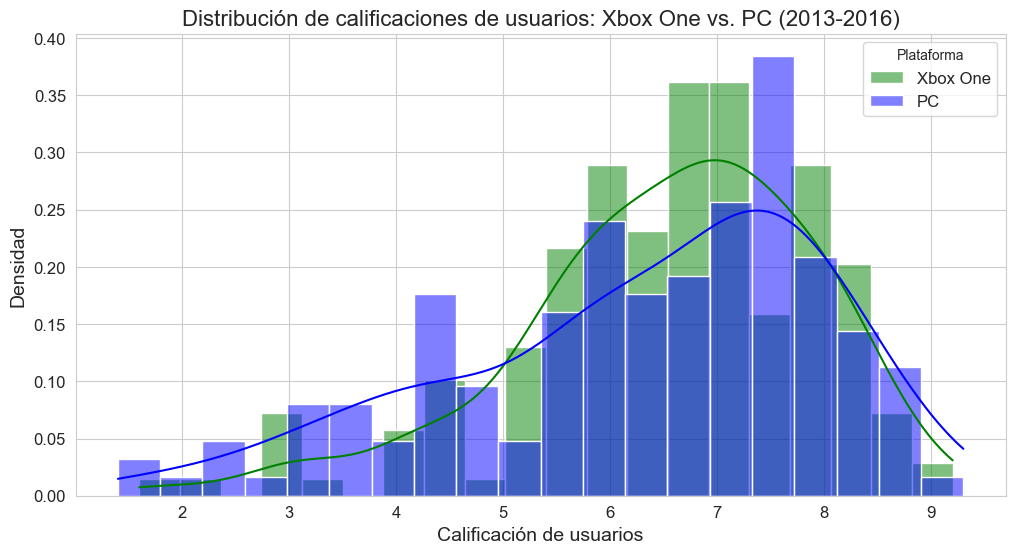

In [269]:
# Histograma y KDE de las calificaciones de Xbox One y PC
plt.figure(figsize=(12, 6))

sns.histplot(juegos_recientes[juegos_recientes['platform'] == 'XOne']['user_score'],
             color='green',
             label='Xbox One',
             kde=True,
             stat="density",
             alpha=0.5,
             bins=20)

sns.histplot(juegos_recientes[juegos_recientes['platform'] == 'PC']['user_score'],
             color='blue',
             label='PC',
             kde=True,
             stat="density",
             alpha=0.5,
             bins=20)

plt.title('Distribución de calificaciones de usuarios: Xbox One vs. PC (2013-2016)', fontsize=16)
plt.xlabel('Calificación de usuarios', fontsize=14)
plt.ylabel('Densidad', fontsize=14)
plt.legend(title='Plataforma', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.show()

In [ ]:
from scipy import stats

Ahora hacemos la prueba de Brown-Forsythe para evaluar la homogeneidad de las varianzas entre los dos grupos, con un nivel de significancia de $\alpha = 0.05$, bajo las hipótesis:
- H0: Las varianzas de las calificaciones de los usuarios son iguales entre Xbox One y PC.
- H1: Las varianzas de las calificaciones de los usuarios son diferentes entre Xbox One y PC.

In [278]:
# Ejecutamos la prueba de Brown-Forsythe para comparar la varianza de las calificaciones de usuarios entre Xbox One y PC
xone_user_scores = juegos_recientes[juegos_recientes['platform'] == 'XOne']['user_score'].dropna()
pc_user_scores = juegos_recientes[juegos_recientes['platform'] == 'PC']['user_score'].dropna()

stat_bf, p_value_bf = stats.levene(xone_user_scores, pc_user_scores, center='median')

print(f"Estadístico de Brown-Forsythe: {stat_bf:.4f}")
print(f"p-valor de la prueba de Brown-Forsythe: {p_value_bf:.4f}")

if p_value_bf < 0.05:
    print("Rechazamos la hipótesis nula: las varianzas son significativamente diferentes entre Xbox One y PC.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente para afirmar que las varianzas son diferentes entre Xbox One y PC.")

Estadístico de Brown-Forsythe: 8.3046
p-valor de la prueba de Brown-Forsythe: 0.0042
Rechazamos la hipótesis nula: las varianzas son significativamente diferentes entre Xbox One y PC.


Después de concluir que las varianzas son significativamente diferentes, se realizará la prueba t de Welch para comparar las medias de las calificaciones de los usuarios entre Xbox One y PC, bajo las hipótesis:
- H0: Las calificaciones promedio de los usuarios son iguales entre Xbox One y PC.
- H1: Las calificaciones promedio de los usuarios son diferentes entre Xbox One y PC.

In [279]:
# prueba t de Welch para comparar las calificaciones de usuarios entre Xbox One y PC con varianzas iguales o diferentes

alpha = 0.05

resultados = stats.ttest_ind(xone_user_scores, pc_user_scores, equal_var=False)
print(f"Estadístico t: {resultados.statistic:.4f}")
print(f"p-valor: {resultados.pvalue:.4f}")

if resultados.pvalue < alpha:
    print("Rechazamos la hipótesis nula: las calificaciones de usuarios son significativamente diferentes entre Xbox One y PC.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente para afirmar que las calificaciones de usuarios son diferentes entre Xbox One y PC.")

Estadístico t: 1.4027
p-valor: 0.1617
No rechazamos la hipótesis nula: no hay evidencia suficiente para afirmar que las calificaciones de usuarios son diferentes entre Xbox One y PC.


Al aplicar la prueba t de Welch (justificada por la prueba de Brown-Forsythe), se obtiene un valor de p de 0.16, al ser un valor mayor a nuestro valor de significancia $\alpha = 0.05$, no se rechaza la hipótesis nula. Esto sugiere que no hay evidencia suficiente para concluir que las calificaciones promedio de los usuarios difieren significativamente entre Xbox One y PC, lo que podría indicar que los usuarios perciben una experiencia de juego similar en ambas plataformas, al menos en términos de satisfacción reflejada en las calificaciones.

Esto sugiere que, para la planificación de marketing podemos considerar a Xbox One y PC como plataformas que podrían atraer a un público similar en términos de preferencias de juego, lo que podría ser útil para diseñar campañas publicitarias que resalten las características compartidas entre ambas plataformas o para desarrollar juegos que sean compatibles con ambas, aprovechando la percepción de similitud en la experiencia de juego por parte de los usuarios.

### Acción vs Deportes

Se probará la hipotesis de que las calificaciones promedio de los usuarios no difieren significativamente entre los géneros de Acción y Deportes. Para esto tendremos
- Hipotesis nula (H0): Las calificaciones promedio de los usuarios son iguales entre los géneros de Acción y Deportes.
- Hipotesis alternativa (H1): Las calificaciones promedio de los usuarios son diferentes entre los géneros de Acción y Deportes.

El nivel de significancia se establecerá en **$\alpha = 0.05$**

In [280]:
juegos_recientes[juegos_recientes['genre'].isin(['Action', 'Sports'])].groupby('genre')['name'].count().sort_values(ascending=False)

genre
Action    769
Sports    214
Name: name, dtype: int64

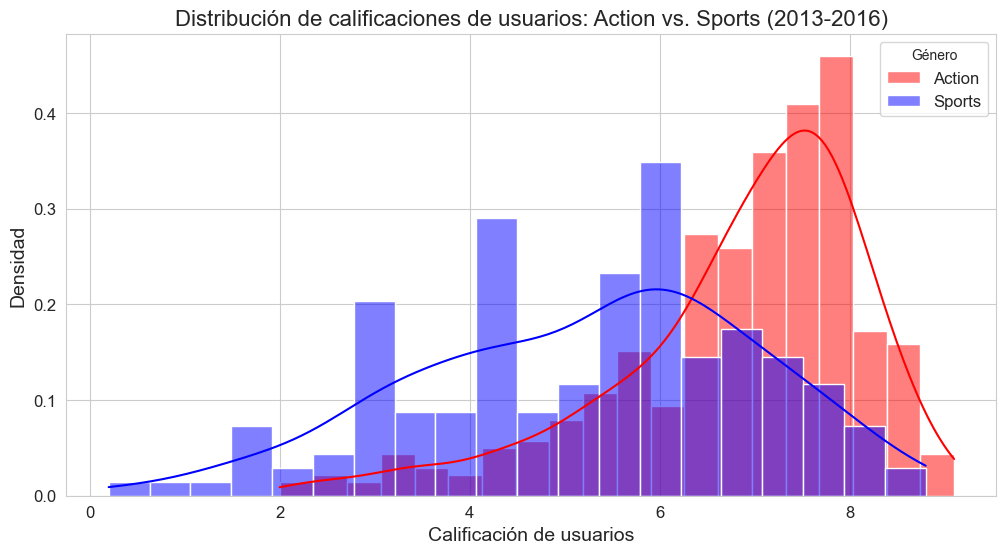

In [281]:
# histograma y KDE de las calificaciones de los géneros Action y Sports
plt.figure(figsize=(12, 6))

sns.histplot(juegos_recientes[juegos_recientes['genre'] == 'Action']['user_score'],
             color='red', kde=True, label='Action', stat='density', bins=20)

sns.histplot(juegos_recientes[juegos_recientes['genre'] == 'Sports']['user_score'],
             color='blue', kde=True, label='Sports', stat='density', bins=20)

plt.title('Distribución de calificaciones de usuarios: Action vs. Sports (2013-2016)', fontsize=16)
plt.xlabel('Calificación de usuarios', fontsize=14)
plt.ylabel('Densidad', fontsize=14)
plt.legend(title='Género', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.show()

Desde la gráfica podemos ver ya diferencias en las distribuciones de las calificaciones de los usuarios entre los géneros de Acción y Deportes, con una mayor dispersión en el género de Acción. Para evaluar la homogeneidad de las varianzas entre los dos grupos, se realizará la prueba de Brown-Forsythe con un nivel de significancia de $\alpha = 0.05$, bajo las hipótesis:
- H0: Las varianzas de las calificaciones de los usuarios son iguales entre los géneros de Acción y Deportes.
- H1: Las varianzas de las calificaciones de los usuarios son diferentes entre los géneros de Acción y Deportes.

In [282]:
juegos_accion = juegos_recientes[juegos_recientes['genre'] == 'Action']['user_score'].dropna()
juegos_sports = juegos_recientes[juegos_recientes['genre'] == 'Sports']['user_score'].dropna()

stat_bf_genre, p_value_bf_genre = stats.levene(juegos_accion, juegos_sports, center='median')

print(f"Estadístico de Brown-Forsythe: {stat_bf_genre:.4f}")
print(f"p-valor de la prueba de Brown-Forsythe: {p_value_bf_genre:.4f}")

if p_value_bf_genre < 0.05:
    print("Rechazamos la hipótesis nula: las varianzas son significativamente diferentes entre los géneros Action y Sports.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente para afirmar que las varianzas son diferentes entre los géneros Action y Sports.")

Estadístico de Brown-Forsythe: 26.2096
p-valor de la prueba de Brown-Forsythe: 0.0000
Rechazamos la hipótesis nula: las varianzas son significativamente diferentes entre los géneros Action y Sports.


Hemos confirmado la diferencia significativa en las varianzas entre los géneros de Acción y Deportes, lo que justifica el uso de la prueba t de Welch para comparar las medias de las calificaciones de los usuarios entre estos dos géneros, bajo las hipótesis:
- H0: Las calificaciones promedio de los usuarios son iguales entre los géneros de Acción y Deportes.
- H1: Las calificaciones promedio de los usuarios son diferentes entre los géneros de Acción y Deportes.

In [283]:
# Prueba T de Welch para comparar las calificaciones de usuarios entre los géneros Action y Sports
alpha = 0.05
resultados_genre = stats.ttest_ind(juegos_accion, juegos_sports, equal_var=False)
print(f"Estadístico t: {resultados_genre.statistic:.4f}")
print(f"p-valor: {resultados_genre.pvalue:.4f}")

if resultados_genre.pvalue < alpha:
    print("Rechazamos la hipótesis nula: las calificaciones de usuarios son significativamente diferentes entre los géneros Action y Sports.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente para afirmar que las calificaciones de usuarios son diferentes entre los géneros Action y Sports.")

Estadístico t: 10.2421
p-valor: 0.0000
Rechazamos la hipótesis nula: las calificaciones de usuarios son significativamente diferentes entre los géneros Action y Sports.


Esto confirma lo que ya se veia en el histograma. El valor p obtenido es menor a 0.0001, lo que indica que se rechaza la hipótesis nula. Esto sugiere que hay evidencia suficiente para concluir que las calificaciones promedio de los usuarios difieren significativamente entre los géneros de Acción y Deportes, lo que podría indicar que los usuarios tienen preferencias claras por ciertos tipos de juegos.

Dada esta diferencia se analizará la distancia de Cohen para evaluar la magnitud de la diferencia entre las calificaciones de los usuarios entre los géneros de Acción y Deportes. Esto nos ayudará a entender no solo si la diferencia es estadísticamente significativa, sino también si es lo suficientemente grande como para ser considerada relevante desde una perspectiva práctica o comercial.

In [284]:
# función de distancia de Cohen
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

In [286]:
print(f"Tamaño del efecto (Cohen's d) entre los géneros de Acción y Deportes: {cohen_d(juegos_accion, juegos_sports):.4f}")

if cohen_d(juegos_accion, juegos_sports) < 0.2:
    print("El tamaño del efecto es pequeño.")
elif cohen_d(juegos_accion, juegos_sports) < 0.5:
    print("El tamaño del efecto es moderado.")
else:
    print("El tamaño del efecto es grande.")

Tamaño del efecto (Cohen's d) entre los géneros de Acción y Deportes: 1.0844
El tamaño del efecto es grande.


Este resultado nos confirma que la diferencia en las calificaciones de los usuarios entre los géneros de Acción y Deportes no solo es estadísticamente significativa, sino que también tiene una magnitud grande, lo que sugiere que los usuarios tienen una mejor relación con los juegos de Acción en comparación con los juegos de Deportes. Esto podría ser útil para los desarrolladores y comercializadores de videojuegos al planificar futuros lanzamientos y estrategias de marketing, ya que podrían enfocarse más en el desarrollo de juegos de Acción o en resaltar las características de los juegos de Acción para atraer a un público que parece tener una preferencia clara por ese género.

### PS4 vs Xbox One

Ahora analizaremos las plataformas líderes en ventas. Se probará la hipotesis de que las calificaciones promedio de los usuarios no difieren significativamente entre las plataformas PS4 y Xbox One. Para esto tendremos
- Hipotesis nula (H0): Las calificaciones promedio de los usuarios son iguales entre PS4 y Xbox One.
- Hipotesis alternativa (H1): Las calificaciones promedio de los usuarios son diferentes entre PS4 y Xbox One.

El nivel de significancia se establecerá en **$\alpha = 0.05$**.

In [287]:
juegos_recientes[juegos_recientes['platform'].isin(['PS4', 'XOne'])].groupby('platform')['name'].count().sort_values(ascending=False)

platform
PS4     392
XOne    247
Name: name, dtype: int64

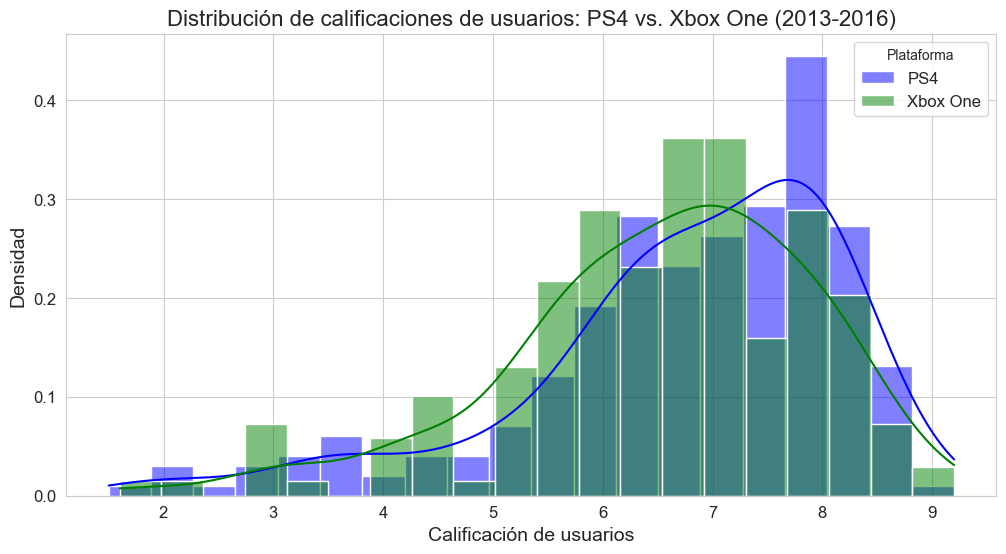

In [290]:
# Histograma y KDE de las calificaciones de usuarios para PS4 y Xbox One
plt.figure(figsize=(12, 6))

sns.histplot(juegos_recientes[juegos_recientes['platform'] == 'PS4']['user_score'],
             color='blue', kde=True, label='PS4', stat="density", bins=20)

sns.histplot(juegos_recientes[juegos_recientes['platform'] == 'XOne']['user_score'],
             color='green', kde=True, label='Xbox One', stat="density", bins=20)

plt.title('Distribución de calificaciones de usuarios: PS4 vs. Xbox One (2013-2016)', fontsize=16)
plt.xlabel('Calificación de usuarios', fontsize=14)
plt.ylabel('Densidad', fontsize=14)
plt.legend(title='Plataforma', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.show()

Ahora se realizará la prueba de Brown-Forsythe para evaluar la homogeneidad de las varianzas entre los dos grupos, con un nivel de significancia de $\alpha = 0.05$, bajo las hipótesis:
- H0: Las varianzas de las calificaciones de los usuarios son iguales entre PS4 y Xbox One.
- H1: Las varianzas de las calificaciones de los usuarios son diferentes entre PS4 y Xbox One.

In [291]:
# Usamos la prueba Brown Forsythe para comparar la varianza de las calificaciones de usuarios entre PS4 y Xbox One
ps4_user_scores = juegos_recientes[juegos_recientes['platform'] == 'PS4']['user_score'].dropna()
xone_user_scores = juegos_recientes[juegos_recientes['platform'] == 'XOne']['user_score'].dropna()

stat_bf_ps4_xone, p_value_bf_ps4_xone = stats.levene(ps4_user_scores, xone_user_scores, center='median')

print(f"Estadístico de Brown-Forsythe: {stat_bf_ps4_xone:.4f}")
print(f"p-valor de la prueba de Brown-Forsythe: {p_value_bf_ps4_xone:.4f}")

if p_value_bf_ps4_xone < 0.05:
    print("Rechazamos la hipótesis nula: las varianzas son significativamente diferentes entre PS4 y Xbox One.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia suficiente para afirmar que las varianzas son diferentes entre PS4 y Xbox One.")

Estadístico de Brown-Forsythe: 0.0792
p-valor de la prueba de Brown-Forsythe: 0.7785
No se rechaza la hipótesis nula: no hay evidencia suficiente para afirmar que las varianzas son diferentes entre PS4 y Xbox One.


Aquí se confirma que las varianzas de las calificaciones de los usuarios entre PS4 y Xbox One no son significativamente diferentes, lo que justifica el uso de la prueba t de Student con varianzas iguales para comparar las medias de las calificaciones de los usuarios entre estas dos plataformas, bajo las hipótesis:
- H0: Las calificaciones promedio de los usuarios son iguales entre PS4 y Xbox One.
- H1: Las calificaciones promedio de los usuarios son diferentes entre PS4 y Xbox One.

In [293]:
# prueba t de student para comparar las calificaciones de usuarios entre PS4 y Xbox One con varianzas iguales o diferentes
alpha = 0.05

resultados_ps4_xone = stats.ttest_ind(ps4_user_scores, xone_user_scores, equal_var=True)
print(f"Estadístico t: {resultados_ps4_xone.statistic:.4f}")
print(f"p-valor: {resultados_ps4_xone.pvalue:.4f}")

if resultados_ps4_xone.pvalue < alpha:
    print("Rechazamos la hipótesis nula: las calificaciones de usuarios son significativamente diferentes entre PS4 y Xbox One.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia suficiente para afirmar que las calificaciones de usuarios son diferentes entre PS4 y Xbox One.")

Estadístico t: 1.6402
p-valor: 0.1017
No se rechaza la hipótesis nula: no hay evidencia suficiente para afirmar que las calificaciones de usuarios son diferentes entre PS4 y Xbox One.


Después de aplicar la prueba t de Student con varianzas iguales, se obtiene un valor de p de 0.10, al ser un valor mayor a nuestro valor de significancia $\alpha = 0.05$, no se rechaza la hipótesis nula. Esto sugiere que no hay evidencia suficiente para concluir que las calificaciones promedio de los usuarios difieren significativamente entre PS4 y Xbox One, lo que podría indicar que los usuarios perciben una experiencia de juego similar en ambas plataformas, al menos en términos de satisfacción reflejada en las calificaciones.

### Región NA vs región EU

Se probará la hipotesis de que las ventas totales de los usuarios no difieren significativamente entre las regiones de Norteamérica y Europa. Para esto tendremos
- Hipotesis nula (H0): Las ventas totales de los usuarios son iguales entre Norteamérica y Europa.
- Hipotesis alternativa (H1): Las ventas totales de los usuarios son diferentes entre Norteamérica y Europa.

El nivel de significancia se establecerá en **$\alpha = 0.05$**.

In [302]:
# Conteo de valores de ventas en na_sales y eu_sales
print("NA Sales:", juegos_recientes['na_sales'].sum())
print("EU Sales:", juegos_recientes['eu_sales'].sum())

NA Sales: 437.79
EU Sales: 392.71


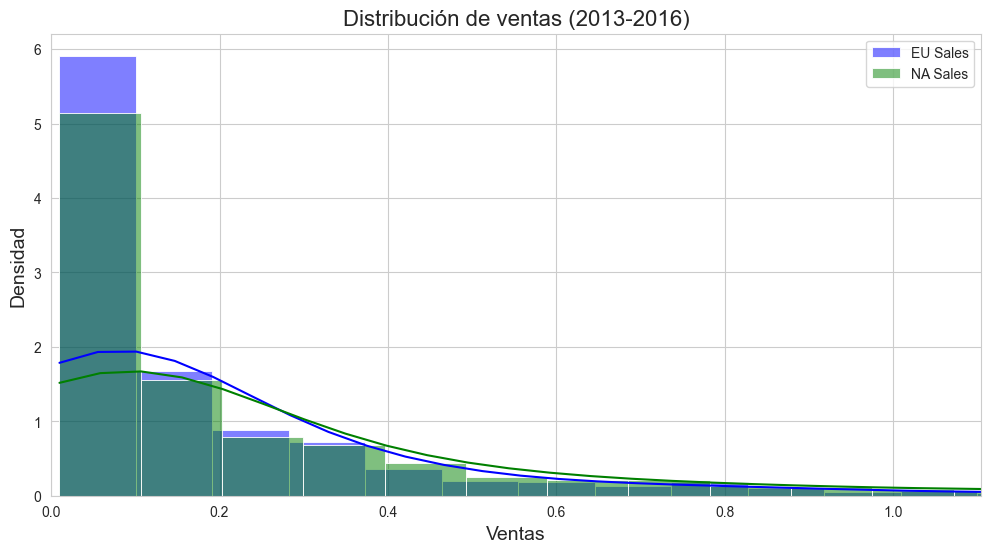

In [311]:
# Histograma y KDE de las ventas para na y eu_sales
eu_sales_scores = juegos_recientes[juegos_recientes['eu_sales'] > 0]['eu_sales'].dropna()
na_sales_scores = juegos_recientes[juegos_recientes['na_sales'] > 0]['na_sales'].dropna()

plt.figure(figsize=(12, 6))

sns.histplot(eu_sales_scores, 
             color='blue', 
             label='EU Sales', 
             kde=True, 
             stat="density", 
             bins=100, 
             alpha=0.5)
sns.histplot(na_sales_scores, 
             color='green', 
             label='NA Sales', 
             kde=True, 
             stat="density", 
             bins=100, 
             alpha=0.5)


plt.title('Distribución de ventas (2013-2016)', fontsize=16)
plt.xlabel('Ventas', fontsize=14)
plt.ylabel('Densidad', fontsize=14)
plt.xlim(0, eu_sales_scores.quantile(0.95))
plt.legend()
plt.show()

Ahora hacemos la prueba de Brown-Forsythe para evaluar la homogeneidad de las varianzas entre los dos grupos, con un nivel de significancia de $\alpha = 0.05$, bajo las hipótesis:
- H0: Las varianzas de las ventas totales de los usuarios son iguales entre Norteamérica y Europa.
- H1: Las varianzas de las ventas totales de los usuarios son diferentes entre Norteamérica y Europa.

In [312]:
# ejecutamos la prueba de Brown-Forsythe para comparar la varianza de las ventas entre NA y EU
stat_bf_sales, p_value_bf_sales = stats.levene(na_sales_scores, eu_sales_scores, center='median')

print(f"Estadístico de Brown-Forsythe: {stat_bf_sales:.4f}")
print(f"p-valor de la prueba de Brown-Forsythe: {p_value_bf_sales:.4f}")

if p_value_bf_sales < 0.05:
    print("Rechazamos la hipótesis nula: las varianzas de ventas son significativamente diferentes entre NA y EU.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia suficiente para afirmar que las varianzas de ventas son diferentes entre NA y EU.")

Estadístico de Brown-Forsythe: 4.1244
p-valor de la prueba de Brown-Forsythe: 0.0424
Rechazamos la hipótesis nula: las varianzas de ventas son significativamente diferentes entre NA y EU.


Se ha rechazado la hipótesis nula, lo que indica que las varianzas de las ventas totales de los usuarios entre Norteamérica y Europa son significativamente diferentes. Esto justifica el uso de la prueba t de Welch para comparar las medias de las ventas totales de los usuarios entre estas dos regiones, bajo las hipótesis:
- H0: Las ventas totales de los usuarios son iguales entre Norteamérica y Europa.
- H1: Las ventas totales de los usuarios son diferentes entre Norteamérica y Europa.

In [313]:
# prueba t de Welch para comparar las calificaciones de usuarios entre las ventas de NA y EU con varianzas iguales o diferentes
alpha = 0.05
resultados_sales = stats.ttest_ind(na_sales_scores, eu_sales_scores, equal_var=False)
print(f"Estadístico t: {resultados_sales.statistic:.4f}")
print(f"p-valor: {resultados_sales.pvalue:.4f}")

if resultados_sales.pvalue < alpha:
    print("Rechazamos la hipótesis nula: las ventas son significativamente diferentes entre NA y EU.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia suficiente para afirmar que las ventas son diferentes entre NA y EU.")


Estadístico t: 2.3354
p-valor: 0.0196
Rechazamos la hipótesis nula: las ventas son significativamente diferentes entre NA y EU.


Hemos encontrado algo intresante, pese a la similitud de las distribuciones de las ventas en la región de Norteamérica y Europa, el valor p obtenido es de 0.0196, al ser un valor menor a nuestro valor de significancia $\alpha = 0.05$, se rechaza la hipótesis nula. Esto sugiere que hay evidencia suficiente para concluir que las ventas totales de los usuarios difieren significativamente entre Norteamérica y Europa, lo que podría indicar que, a pesar de las similitudes en las plataformas líderes y géneros más populares, existen diferencias en el comportamiento de compra.

Se hará una confirmación adicional con una prueba Kolmogorov-Smirnov para comparar las distribuciones de las ventas totales de los usuarios entre Norteamérica y Europa, bajo las hipótesis:
- H0: Las distribuciones de las ventas totales de los usuarios son iguales entre Norteamérica y Europa.
- H1: Las distribuciones de las ventas totales de los usuarios son diferentes entre Norteamérica y Europa.

In [315]:
# prueba kolmogorov-smirnov para comparar la distribución de las ventas entre NA y EU
stat_ks_sales, p_value_ks_sales = stats.ks_2samp(na_sales_scores, eu_sales_scores)
print(f"Estadístico de Kolmogorov-Smirnov: {stat_ks_sales:.4f}")
print(f"p-valor de la prueba de Kolmogorov-Smirnov: {p_value_ks_sales:.4f}")

if p_value_ks_sales < alpha:
    print("Rechazamos la hipótesis nula: las distribuciones de ventas son significativamente diferentes entre NA y EU.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia suficiente para afirmar que las distribuciones de ventas son diferentes entre NA y EU.")

Estadístico de Kolmogorov-Smirnov: 0.0672
p-valor de la prueba de Kolmogorov-Smirnov: 0.0040
Rechazamos la hipótesis nula: las distribuciones de ventas son significativamente diferentes entre NA y EU.


Ante esta diferencia procedemos a analizar la distancia de Cohen para evaluar la magnitud de la diferencia entre las ventas totales de los usuarios entre Norteamérica y Europa. Esto nos ayudará a entender no solo si la diferencia es estadísticamente significativa, sino también si es lo suficientemente grande como para ser considerada relevante desde una perspectiva práctica o comercial.

In [314]:
# usamos la función de distancia de Cohen para calcular el tamaño del efecto entre las ventas de NA y EU
print(f"Tamaño del efecto (Cohen's d) entre las ventas de NA y EU: {cohen_d(na_sales_scores, eu_sales_scores):.4f}")

if cohen_d(na_sales_scores, eu_sales_scores) < 0.2:
    print("El tamaño del efecto es pequeño.")
elif cohen_d(na_sales_scores, eu_sales_scores) < 0.5:
    print("El tamaño del efecto es moderado.")
else:
    print("El tamaño del efecto es grande.")

Tamaño del efecto (Cohen's d) entre las ventas de NA y EU: 0.0897
El tamaño del efecto es pequeño.


Si bien la prueba de hipótesis indicó una diferencia estadísticamente significativa, por el tamaño y sencibilidad de las pruebas; entre las ventas totales de los usuarios en Norteamérica y Europa, la distancia de Cohen obtenida es de 0.0879, lo que sugiere que la magnitud de la diferencia es pequeña y podría no ser relevante desde una perspectiva práctica o comercial.

La magnitud de la diferencia en las ventas totales de los usuarios entre Norteamérica y Europa es pequeña, lo que sugiere que, aunque hay una diferencia estadísticamente significativa, esta diferencia podría no ser lo suficientemente grande como para tener un impacto significativo en las estrategias de marketing o desarrollo de videojuegos. Esto podría indicar que, a pesar de las diferencias en el comportamiento de compra, las preferencias de los consumidores en ambas regiones son lo suficientemente similares como para permitir estrategias de marketing y desarrollo de juegos que puedan ser efectivas en ambos mercados sin necesidad de adaptaciones significativas.

## Fase 6. Conclusiones generales

El propósito general del análisis de datos fue identificar patrones que determinen si un videojuego tiene éxito o no, para esto se analizaron diferentes aspectos relacionados con las plataformas, géneros y regiones. A continuación se presentan las conclusiones generales basadas en los análisis realizados:

1. **Ciclo de vida de las plataformas**: Las plataformas de videojuegos tienen un ciclo de vida promedio de alrededor de 6 años, con una mediana también de 6 años. Esto sugiere que las plataformas tienden a desaparecer o entrar en declive después de aproximadamente 6 años en el mercado, aunque algunos factores como el éxito de juegos exclusivos o la lealtad de los usuarios pueden extender este ciclo.
2. **Tiempo de reaparición de las plataformas**: El tiempo promedio que tarda en reaparecer una nueva generación de plataforma es de aproximadamente 6.83 años, lo que sugiere que las empresas de videojuegos lanzan nuevas generaciones de plataformas aproximadamente cada 6 a 7 años, posiblemente para mantener el interés de los consumidores y asegurar una transición suave entre generaciones.
3. **Plataformas líderes en ventas**: Durante el período de 2013 a 2016, las plataformas líderes en ventas fueron PlayStation 4 (PS4) y Xbox One. Estas plataformas podrían aún encontrarse en fase de crecimiento, lo que sugiere que podrían seguir generando altos ingresos en el futuro si continúan lanzando juegos exitosos y manteniendo el interés de los consumidores.
4. **Dispersión de ventas globales por plataforma**: Las plataformas líderes en ventas, como PS4 y Xbox One, tienen una mayor dispersión en las ventas de sus juegos, con algunos títulos alcanzando un gran éxito comercial mientras que la mayoría no logra generar ventas significativas. Esto sugiere que el éxito de los videojuegos en estas plataformas es altamente variable.
5. **Relación entre opiniones de usuarios y ventas**: En las plataformas líderes en ventas, se observó una ligera correlación positiva entre las ventas globales y las calificaciones de los críticos, pero no una correlación significativa entre las ventas globales y las calificaciones de los usuarios. Esto podría indicar que las calificaciones de los críticos tienen un mayor impacto en el éxito comercial de los videojuegos que las calificaciones de los usuarios en estas plataformas.
6. **Comparación de ventas por género**: Los géneros más rentables fueron Action, Shooter, Sports y Role-Playing, mientras que los géneros con menos ventas globales fueron Puzzle y Strategy. Esto sugiere que los consumidores tienen una preferencia por ciertos tipos de juegos, lo que podría ser útil para los desarrolladores y comercializadores de videojuegos al planificar futuros lanzamientos y estrategias de marketing.
7. **Variaciones de las cuotas de mercado entre regiones**: En Norteamérica y Europa la plataforma líder en ventas fue PlayStation 4 (PS4), mientras que en Japón la plataforma líder en ventas fue Nintendo 3DS (3DS). Esto podría indicar que los consumidores japoneses tienen una preferencia por los juegos disponibles en 3DS, lo que podría estar relacionado con la popularidad de ciertos géneros de juegos o con la presencia de títulos exclusivos para esa plataforma que resuenan más con el público japonés.
8. **Clasificaciones de ESRB y ventas por región**: En Norteamérica y Europa, la clasificación M (Mature 17+) tuvo más ventas, seguida por E (Everyone), lo que podría indicar que los consumidores en estas regiones tienen una preferencia por juegos con contenido más maduro. En Japón, la clasificación con mayor número de ventas fue 'unknown', lo que podría indicar que una gran cantidad de juegos populares en esa región no tienen una clasificación de ESRB asignada, lo que podría deberse a diferencias en los sistemas de clasificación de contenido entre regiones o a la presencia de juegos exclusivos para el mercado japonés que no siguen las mismas pautas de clasificación.
9. **Análisis inferencial**: Se realizaron pruebas de hipótesis para comparar las calificaciones de los usuarios entre Xbox One y PC, entre los géneros de Acción y Deportes, entre PS4 y Xbox One, y entre las regiones de Norteamérica y Europa. Se encontró que no hay diferencias significativas en las calificaciones de los usuarios entre Xbox One y PC, ni entre PS4 y Xbox One. Sin embargo, sí se encontró una diferencia significativa en las calificaciones de los usuarios entre los géneros de Acción y Deportes, con una magnitud grande, lo que sugiere que los usuarios tienen una mejor relación con los juegos de Acción en comparación con los juegos de Deportes. Además, se encontró una diferencia significativa en las ventas totales de los usuarios entre Norteamérica y Europa, aunque la magnitud de esta diferencia es pequeña, lo que sugiere que las preferencias de los consumidores en ambas regiones son lo suficientemente similares como para permitir estrategias de marketing y desarrollo de juegos que puedan ser efectivas en ambos mercados sin necesidad de adaptaciones significativas.


**Conclusiones generales**: En general, el análisis de datos sugiere que el éxito de un videojuego está influenciado por una combinación de factores relacionados con la plataforma, el género y la región. Las plataformas líderes en ventas tienden a tener una mayor dispersión en las ventas de sus juegos, y las calificaciones de los críticos parecen tener un mayor impacto en el éxito comercial que las calificaciones de los usuarios. Además, ciertos géneros de juegos son más populares que otros, y las preferencias de los consumidores pueden variar entre regiones. Estas conclusiones pueden ser útiles para los desarrolladores y comercializadores de videojuegos al planificar futuros lanzamientos y estrategias de marketing.